# 1.1 Red neuronal usando Python

Partiendo de las nociones teóricas y prácticas vistas en la unidad, el alumno va a diseñar y desarrollar una red neuronal aplicada en el área de su interés. Tanto el diseño como el código deben ser entregados describiendo detalladamente cada uno de los procesos involucrados, así como la justificación y pertinencia de su implementación.


**Alumno:** Marco Sebastián Hernández Parada
**Materia:** Aprendizaje profundo — Unidad 1
**Práctica:** 1.1 Red neuronal usando Python

## Índice

1. Objetivo y justificación del problema
2. Entorno de trabajo: versión de Python y dependencias
3. Fundamentos teóricos de las redes neuronales
4. Generación del conjunto de datos (anillo / dona)
5. Preprocesamiento
6. Implementación de la red neuronal desde cero con NumPy
7. Verificación numérica de los gradientes
8. Experimento 1: modelo **sin** capa oculta (¿por qué no basta?)
9. Experimento 2: red neuronal multicapa
10. Análisis de resultados y visualización de lo aprendido
11. Experimentos de sensibilidad (neuronas, tasa de aprendizaje, activación, ruido)
12. Comparación con scikit-learn
13. Predicción de puntos nuevos
14. Conclusiones
15. Referencias

## 1. Objetivo y justificación del problema

### Objetivo

Diseñar, implementar **desde cero** (solo con NumPy) y analizar una red neuronal multicapa (MLP, *Multilayer Perceptron*) capaz de resolver un problema de **clasificación binaria no lineal**: decidir si un punto del plano cae **dentro de un anillo** (una "dona") o fuera de él.

### El problema

Cada ejemplo es un punto $(x_1, x_2)$ del plano. Su distancia al origen es $r = \sqrt{x_1^2 + x_2^2}$ y su etiqueta es:

$$
y = \begin{cases} 1 & \text{si } r_1 \le r \le r_2 \quad \text{(el punto está en el anillo)} \\ 0 & \text{en otro caso (centro o exterior)} \end{cases}
$$

### ¿Por qué este problema?

- **Es el "hermano mayor" de XOR.** La compuerta XOR es el ejemplo histórico que demostró (Minsky y Papert, 1969) que un perceptrón de una sola capa no puede resolver problemas que no son *linealmente separables*. El anillo tiene la misma propiedad: **no existe ninguna recta** que separe los puntos del anillo de los del centro y del exterior, porque la clase 0 está a *ambos lados* de la clase 1.
- **Es continuo y visual.** XOR solo tiene 4 puntos; aquí tenemos cientos de puntos en 2D, lo que permite **dibujar la frontera de decisión** que aprende la red y ver literalmente cómo "piensa".
- **Es pequeño.** Dos entradas y unas cuantas neuronas bastan, así que todo el proceso (propagación hacia adelante, retropropagación, descenso de gradiente) puede escribirse y explicarse línea por línea, sin cajas negras.
- **Conocemos la respuesta correcta.** Como nosotros generamos los datos, sabemos exactamente cuál es la frontera ideal (dos circunferencias) y podemos comparar contra ella lo que aprendió la red.

### Qué se va a demostrar

1. Un modelo lineal (neurona única, sin capa oculta) **fracasa** en este problema.
2. Al agregar capas ocultas con funciones de activación no lineales, la red **aprende una frontera circular** sin que nadie le diga que la solución depende del radio.
3. Cada neurona oculta de la primera capa solo sabe trazar una **recta**; la red combina esas rectas para construir la forma del anillo.

## 2. Entorno de trabajo: versión de Python y dependencias

La práctica se desarrolló y ejecutó con el siguiente entorno:

| Componente | Versión utilizada | Uso en la práctica |
|---|---|---|
| **Python** | 3.13.7 | Lenguaje base |
| **NumPy** | 2.3.3 | Álgebra lineal: implementación completa de la red (pesos, forward, backpropagation) |
| **Matplotlib** | 3.10.7 | Gráficas: datos, fronteras de decisión, curvas de aprendizaje |
| **scikit-learn** | 1.7.2 | Solo utilidades: división entrenamiento/prueba, métricas y un `MLPClassifier` de referencia para comparar |
| **Jupyter / ipykernel** | 6.30.1 | Ejecución del cuaderno |

> **Nota:** la red neuronal **no** usa ningún framework de aprendizaje profundo (PyTorch, TensorFlow, Keras). Todo el aprendizaje está escrito a mano con NumPy para poder explicar cada paso.

### Instalación

Desde una terminal (o descomentando la línea `%pip` de la siguiente celda):

```bash
pip install numpy matplotlib scikit-learn
```

La siguiente celda imprime las versiones reales del entorno en el que se ejecuta el cuaderno, para que los resultados sean reproducibles.

In [26]:
# Si falta alguna dependencia, descomenta la siguiente línea y ejecútala una vez:
# %pip install numpy matplotlib scikit-learn

import sys        # Información del intérprete de Python
import platform   # Información del sistema operativo

import numpy as np                 # Cálculo numérico: aquí vive toda la red neuronal
import matplotlib                  # Solo para consultar su versión
import matplotlib.pyplot as plt    # Gráficas
import sklearn                     # Solo para consultar su versión

print(f"Python        : {sys.version}")
print(f"Sistema       : {platform.system()} {platform.release()} ({platform.machine()})")
print(f"NumPy         : {np.__version__}")
print(f"Matplotlib    : {matplotlib.__version__}")
print(f"scikit-learn  : {sklearn.__version__}")

Python        : 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
Sistema       : Windows 10 (AMD64)
NumPy         : 2.3.3
Matplotlib    : 3.10.7
scikit-learn  : 1.7.2


In [27]:
import copy       # Para copiar redes completas (pesos incluidos) sin compartir memoria
import time       # Para medir tiempos de entrenamiento
import warnings   # Para silenciar avisos esperados de scikit-learn

from matplotlib.patches import Circle                           # Dibujar las circunferencias reales r1 y r2
from sklearn.model_selection import train_test_split            # División estratificada de los datos
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.neural_network import MLPClassifier                 # Red de referencia (solo para comparar)
from sklearn.exceptions import ConvergenceWarning

# Semilla global: fija todos los números aleatorios para que cada ejecución
# del cuaderno produzca exactamente los mismos datos, pesos y resultados.
SEMILLA = 42

# Parámetros geométricos del problema (se usan en todo el cuaderno)
R1 = 0.5      # Radio interior del anillo
R2 = 1.0      # Radio exterior del anillo
R_MAX = 1.3   # Radio máximo en el que se generan puntos

# Estilo general de las gráficas
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.grid": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

# Colores fijos para cada clase: 0 = fuera del anillo, 1 = dentro del anillo
COLOR_CLASE = {0: "#d95f02", 1: "#1b9e77"}
NOMBRE_CLASE = {0: "Fuera del anillo (0)", 1: "Dentro del anillo (1)"}

## 3. Fundamentos teóricos de las redes neuronales

> Esta sección sigue el tratamiento de Goodfellow, Bengio y Courville (2016, cap. 6) y de Nielsen (2015), adaptado al problema del anillo.

### 3.1 La neurona artificial

Una neurona artificial es una función muy simple. Recibe un vector de entradas $\mathbf{x} = (x_1, \dots, x_n)$ y hace dos cosas:

1. **Combinación lineal (pre-activación):** multiplica cada entrada por un **peso** $w_i$ y suma un **sesgo** (*bias*) $b$:
$$
z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b
$$
2. **Activación:** aplica una función no lineal $g$:
$$
a = g(z)
$$

Los pesos indican *cuánto importa* cada entrada y el sesgo desplaza el umbral de activación. **Aprender** significa encontrar los valores de $\mathbf{w}$ y $b$ que hacen que la red se equivoque lo menos posible.

**Interpretación geométrica (clave para esta práctica):** en 2D, la ecuación $z = w_1 x_1 + w_2 x_2 + b = 0$ es una **recta**. Una neurona sola divide el plano en dos semiplanos: de un lado $z>0$ y del otro $z<0$. Por eso una sola neurona nunca podrá encerrar un anillo.

### 3.2 Funciones de activación

Si no hubiera activación (o si fuera lineal), apilar capas no serviría de nada: la composición de funciones lineales **sigue siendo lineal**. La no linealidad es lo que da poder expresivo a la red. Las más comunes:

| Función | Fórmula | Derivada | Rango | Comentario |
|---|---|---|---|---|
| Sigmoide | $\sigma(z) = \dfrac{1}{1+e^{-z}}$ | $\sigma(z)(1-\sigma(z))$ | $(0,1)$ | Se interpreta como probabilidad → se usa en la **salida** |
| Tangente hiperbólica | $\tanh(z)$ | $1-\tanh^2(z)$ | $(-1,1)$ | Centrada en cero → buena para capas ocultas pequeñas |
| ReLU | $\max(0, z)$ | $1$ si $z>0$, $0$ si no | $[0,\infty)$ | La más usada en redes profundas; barata de calcular |

### 3.3 Perceptrón multicapa (MLP)

Las neuronas se organizan en **capas**. La salida de una capa es la entrada de la siguiente. Para una capa $l$ con $n_l$ neuronas, y procesando $m$ ejemplos a la vez (en forma matricial):

$$
\mathbf{Z}^{[l]} = \mathbf{A}^{[l-1]} \mathbf{W}^{[l]\top} + \mathbf{b}^{[l]}, \qquad \mathbf{A}^{[l]} = g^{[l]}\!\left(\mathbf{Z}^{[l]}\right)
$$

donde $\mathbf{A}^{[0]} = \mathbf{X}$ (los datos, de tamaño $m \times 2$), $\mathbf{W}^{[l]}$ tiene tamaño $n_l \times n_{l-1}$ y $\mathbf{b}^{[l]}$ tiene tamaño $1 \times n_l$. A este cálculo capa por capa se le llama **propagación hacia adelante** (*forward propagation*).

#### 3.3.1 ¿Qué significa cada símbolo?

| Símbolo | Tamaño | Significado |
|---|---|---|
| $l$ | — | Número de capa. El superíndice $[l]$ **no es una potencia**, solo indica "de la capa $l$". La capa 0 es la entrada |
| $m$ | — | Número de ejemplos (puntos) que se procesan a la vez, por ejemplo un mini-lote de 16 |
| $n_l$ | — | Número de neuronas de la capa $l$. En la red `[2, 8, 8, 1]`: $n_0 = 2,\ n_1 = 8,\ n_2 = 8,\ n_3 = 1$ |
| $\mathbf{A}^{[l-1]}$ | $m \times n_{l-1}$ | **Entradas** de la capa: cada **fila** es un ejemplo y cada columna la salida de una neurona de la capa anterior |
| $\mathbf{W}^{[l]}$ | $n_l \times n_{l-1}$ | **Pesos**: la **fila $j$** contiene los pesos de la neurona $j$, uno por cada entrada que recibe |
| $\mathbf{W}^{[l]\top}$ | $n_{l-1} \times n_l$ | La transpuesta de $\mathbf{W}$ (filas ↔ columnas), necesaria para que los tamaños encajen |
| $\mathbf{b}^{[l]}$ | $1 \times n_l$ | **Sesgos**: uno por neurona |
| $\mathbf{Z}^{[l]}$ | $m \times n_l$ | **Pre-activaciones**: el valor $z$ de cada neurona para cada ejemplo |
| $g^{[l]}$ | — | Función de activación, aplicada **elemento por elemento** |
| $\mathbf{A}^{[l]}$ | $m \times n_l$ | **Salidas** (activaciones) de la capa; serán las entradas de la capa $l+1$ |

#### 3.3.2 La fórmula es solo la neurona de la sección 3.1, repetida

Si miramos **un solo elemento** de la matriz $\mathbf{Z}^{[l]}$ (el ejemplo $i$ en la neurona $j$), la multiplicación de matrices se desarrolla así:

$$
z^{[l]}_{ij} = \sum_{k=1}^{n_{l-1}} a^{[l-1]}_{ik}\, w^{[l]}_{jk} + b^{[l]}_j = \underbrace{\mathbf{w}^{[l]}_j \cdot \mathbf{a}^{[l-1]}_i}_{\text{producto punto}} + b^{[l]}_j
$$

Es exactamente $z = \mathbf{w}^\top\mathbf{x} + b$ de la neurona individual: la neurona $j$ multiplica cada entrada del ejemplo $i$ por su peso correspondiente, suma todo y agrega su sesgo. La notación matricial simplemente hace **todas las neuronas y todos los ejemplos a la vez** en una sola operación, lo cual es mucho más rápido en NumPy que usar ciclos `for`.

**¿Por qué aparece la transpuesta $\mathbf{W}^\top$?** Porque guardamos los ejemplos en **filas** de $\mathbf{A}$ y los pesos de cada neurona también en **filas** de $\mathbf{W}$. Para hacer "fila de $\mathbf{A}$ · fila de $\mathbf{W}$" hay que convertir las filas de $\mathbf{W}$ en columnas. Al multiplicar, los tamaños internos deben coincidir:

$$
\underbrace{\mathbf{A}^{[l-1]}}_{m \times n_{l-1}} \;\cdot\; \underbrace{\mathbf{W}^{[l]\top}}_{n_{l-1} \times n_l} \;=\; \underbrace{\mathbf{Z}^{[l]}}_{m \times n_l}
$$

> En muchos libros (p. ej. Nielsen, 2015) los ejemplos se guardan en **columnas** y la fórmula aparece como $\mathbf{Z} = \mathbf{W}\mathbf{A} + \mathbf{b}$, sin transpuesta. Es la misma operación con otra convención de acomodo.

**¿Cómo se suma $\mathbf{b}$ si tiene otro tamaño?** $\mathbf{A}\mathbf{W}^\top$ es $m \times n_l$ y $\mathbf{b}$ es $1 \times n_l$. NumPy aplica *broadcasting*: suma el mismo vector de sesgos a **cada fila**, es decir, cada neurona usa su mismo sesgo para todos los ejemplos.

**La segunda parte, $\mathbf{A}^{[l]} = g^{[l]}(\mathbf{Z}^{[l]})$**, aplica la activación a cada número de la matriz por separado; el tamaño no cambia.

#### 3.3.3 Ejemplo numérico

Una capa con **2 entradas y 3 neuronas** procesando **2 puntos** ($m = 2$), con activación $\tanh$:

$$
\mathbf{A}^{[0]} = \begin{bmatrix} 0.5 & 1.0 \\ -1.0 & 0.0 \end{bmatrix}
\quad
\mathbf{W}^{[1]} = \begin{bmatrix} 1 & -1 \\ 0.5 & 2 \\ -1 & 0 \end{bmatrix}
\quad
\mathbf{b}^{[1]} = \begin{bmatrix} 0 & 0.5 & 1 \end{bmatrix}
$$

Primer punto $(0.5,\ 1.0)$:
- Neurona 1: $0.5(1) + 1.0(-1) + 0 = -0.5$
- Neurona 2: $0.5(0.5) + 1.0(2) + 0.5 = 2.75$
- Neurona 3: $0.5(-1) + 1.0(0) + 1 = 0.5$

Segundo punto $(-1.0,\ 0.0)$:
- Neurona 1: $-1.0(1) + 0(-1) + 0 = -1$
- Neurona 2: $-1.0(0.5) + 0(2) + 0.5 = 0$
- Neurona 3: $-1.0(-1) + 0(0) + 1 = 2$

$$
\mathbf{Z}^{[1]} = \begin{bmatrix} -0.5 & 2.75 & 0.5 \\ -1 & 0 & 2 \end{bmatrix}
\quad\xrightarrow{\ \tanh\ }\quad
\mathbf{A}^{[1]} = \begin{bmatrix} -0.462 & 0.992 & 0.462 \\ -0.762 & 0 & 0.964 \end{bmatrix}
$$

Cada **fila** de $\mathbf{A}^{[1]}$ es la nueva representación de un punto: el punto ya no se describe con 2 coordenadas, sino con las 3 respuestas de las neuronas. Esa matriz de $2 \times 3$ es la entrada de la siguiente capa. (Al final de la sección 3 hay una celda de código que comprueba este cálculo con NumPy).

#### 3.3.4 Recorrido completo por la red `[2, 8, 8, 1]`

Con un mini-lote de $m = 16$ puntos, los tamaños van cambiando así:

| Capa | Operación | Tamaños | Resultado |
|---|---|---|---|
| 1 (oculta) | $\mathbf{Z}^{[1]} = \mathbf{X}\,\mathbf{W}^{[1]\top} + \mathbf{b}^{[1]}$, $\ \mathbf{A}^{[1]} = \tanh(\mathbf{Z}^{[1]})$ | $(16\times2)(2\times8) + (1\times8)$ | $16 \times 8$ |
| 2 (oculta) | $\mathbf{Z}^{[2]} = \mathbf{A}^{[1]}\mathbf{W}^{[2]\top} + \mathbf{b}^{[2]}$, $\ \mathbf{A}^{[2]} = \tanh(\mathbf{Z}^{[2]})$ | $(16\times8)(8\times8) + (1\times8)$ | $16 \times 8$ |
| 3 (salida) | $\mathbf{Z}^{[3]} = \mathbf{A}^{[2]}\mathbf{W}^{[3]\top} + \mathbf{b}^{[3]}$, $\ \hat{\mathbf{Y}} = \sigma(\mathbf{Z}^{[3]})$ | $(16\times8)(8\times1) + (1\times1)$ | $16 \times 1$ |

Al final queda **una probabilidad por punto**. Escrito para un solo punto $\mathbf{x}$, la red completa es una **composición de funciones**:

$$
\hat{y} = \sigma\Big(\mathbf{W}^{[3]}\,\tanh\big(\mathbf{W}^{[2]}\,\tanh(\mathbf{W}^{[1]}\mathbf{x} + \mathbf{b}^{[1]}) + \mathbf{b}^{[2]}\big) + \mathbf{b}^{[3]}\Big)
$$

En el código de la sección 6 toda esta fórmula corresponde a una sola línea dentro de un ciclo sobre las capas, en el método `_forward`:
```python
Z = A @ self.W[l].T + self.b[l]   # Z^[l] = A^[l-1] · W^[l]ᵀ + b^[l]
A = self.g(Z)                     # A^[l] = g(Z^[l])
```
(en Python las listas empiezan en 0, así que `self.W[0]` es $\mathbf{W}^{[1]}$).

#### 3.3.5 ¿Por qué es indispensable $g$?

Si quitáramos la activación, dos capas seguidas quedarían:

$$
\mathbf{Z}^{[2]} = \big(\mathbf{A}^{[0]}\mathbf{W}^{[1]\top} + \mathbf{b}^{[1]}\big)\mathbf{W}^{[2]\top} + \mathbf{b}^{[2]}
= \mathbf{A}^{[0]}\underbrace{\big(\mathbf{W}^{[2]}\mathbf{W}^{[1]}\big)^{\top}}_{\text{una sola matriz}} + \underbrace{\big(\mathbf{b}^{[1]}\mathbf{W}^{[2]\top} + \mathbf{b}^{[2]}\big)}_{\text{un solo sesgo}}
$$

que es otra vez **una sola capa lineal**: sin importar cuántas capas apilemos, la frontera seguiría siendo una recta. La función $g$ "dobla" el espacio entre capa y capa, y eso es lo que permite construir formas como el anillo.

**¿Por qué funcionan las capas ocultas?** Cada neurona de la primera capa oculta traza una recta. La capa siguiente combina (suma ponderada + no linealidad) esas "regiones de semiplano", de modo que puede formar **intersecciones y uniones** de ellas: polígonos, bandas, y con suficientes neuronas, cualquier forma. Esto se formaliza en el **Teorema de aproximación universal** (Cybenko, 1989; Hornik, 1991): una red con una capa oculta y suficientes neuronas puede aproximar cualquier función continua en un dominio acotado.

### 3.4 Función de pérdida: entropía cruzada binaria

Para medir qué tan equivocada está la red usamos la **entropía cruzada binaria** (*binary cross-entropy*, BCE). Si $\hat{y}_i \in (0,1)$ es la probabilidad predicha y $y_i \in \{0,1\}$ la etiqueta real:

$$
\mathcal{L} = -\frac{1}{m}\sum_{i=1}^{m}\Big[\, y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \,\Big]
$$

Si la red dice "95 % seguro que es 1" y era 1, la pérdida es pequeña ($-\log 0.95 \approx 0.05$). Si dice "95 % seguro que es 1" y era 0, la pérdida es grande ($-\log 0.05 \approx 3$). Castiga mucho los errores cometidos con confianza.

### 3.5 Retropropagación (*backpropagation*)

Para mejorar, necesitamos saber **cómo cambia la pérdida si movemos un poco cada peso**, es decir, el gradiente $\partial \mathcal{L} / \partial \mathbf{W}^{[l]}$. La retropropagación (Rumelhart, Hinton y Williams, 1986) calcula todos esos gradientes de forma eficiente aplicando la **regla de la cadena** desde la salida hacia la entrada.

#### 3.5.1 La idea: la regla de la cadena

La pérdida depende de un peso de la primera capa de manera **indirecta**: ese peso cambia $z$, que cambia la activación $a$, que cambia la $z$ de la capa siguiente, y así hasta la predicción $\hat{y}$, que finalmente cambia $\mathcal{L}$. La regla de la cadena dice que para obtener la derivada total hay que **multiplicar** las derivadas de cada eslabón:

$$
\frac{\partial \mathcal{L}}{\partial w^{[1]}} =
\frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot
\frac{\partial \hat{y}}{\partial z^{[3]}} \cdot
\frac{\partial z^{[3]}}{\partial a^{[2]}} \cdot
\frac{\partial a^{[2]}}{\partial z^{[2]}} \cdot
\frac{\partial z^{[2]}}{\partial a^{[1]}} \cdot
\frac{\partial a^{[1]}}{\partial z^{[1]}} \cdot
\frac{\partial z^{[1]}}{\partial w^{[1]}}
$$

**¿Por qué "hacia atrás"?** Porque los factores de la izquierda se repiten para *todos* los pesos de las capas anteriores. Si empezamos por el final y vamos guardando el producto acumulado, cada capa reutiliza el trabajo de la capa posterior. El costo total es aproximadamente el de **una pasada hacia adelante más una hacia atrás**, sin importar cuántos parámetros haya. La alternativa ingenua (mover un peso a la vez y volver a evaluar la red, como en la verificación de la sección 7) costaría dos pasadas **por cada parámetro**: para nuestra red de 105 parámetros sería ~100 veces más lento, y para una red moderna con millones de parámetros, imposible.

**Notación.** Por comodidad se escribe $\mathbf{dZ}^{[l]} \equiv \partial \mathcal{L}/\partial \mathbf{Z}^{[l]}$, y lo mismo para $\mathbf{dW}$, $\mathbf{db}$ y $\mathbf{dA}$. Cada uno de estos objetos tiene **exactamente el mismo tamaño** que la matriz que deriva: $\mathbf{dW}^{[l]}$ es $n_l \times n_{l-1}$ igual que $\mathbf{W}^{[l]}$, y $\mathbf{dZ}^{[l]}$ es $m \times n_l$ igual que $\mathbf{Z}^{[l]}$. Esta comprobación de tamaños es la mejor forma de detectar errores al programar backpropagation.

#### 3.5.2 Capa de salida: por qué $\mathbf{dZ}^{[L]} = \hat{\mathbf{Y}} - \mathbf{Y}$

Este resultado parece demasiado simple, pero sale de una cancelación exacta entre la pérdida y la sigmoide. Para un solo ejemplo, con $\hat{y} = \sigma(z)$:

$$
\frac{\partial \mathcal{L}}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}} = \frac{\hat{y}-y}{\hat{y}(1-\hat{y})},
\qquad
\frac{\partial \hat{y}}{\partial z} = \sigma'(z) = \hat{y}(1-\hat{y})
$$

Al multiplicarlos (regla de la cadena), el denominador se cancela con la derivada de la sigmoide:

$$
\frac{\partial \mathcal{L}}{\partial z} = \frac{\hat{y}-y}{\hat{y}(1-\hat{y})} \cdot \hat{y}(1-\hat{y}) = \hat{y} - y
$$

Es decir, **el gradiente en la salida es simplemente el error de predicción**. Esta es una de las razones por las que la entropía cruzada se usa con la sigmoide en lugar del error cuadrático: con el error cuadrático quedaría un factor $\sigma'(z)$ suelto que vale casi cero cuando la red se equivoca con mucha confianza, y el aprendizaje se frenaría justo cuando más falta hace.

#### 3.5.3 De $\mathbf{dZ}$ a los gradientes de los parámetros

Una vez que sabemos cuánto "culpa" tiene cada pre-activación, los gradientes de los parámetros de esa capa salen de $\mathbf{Z}^{[l]} = \mathbf{A}^{[l-1]}\mathbf{W}^{[l]\top} + \mathbf{b}^{[l]}$:

$$
\mathbf{dW}^{[l]} = \frac{1}{m}\,\mathbf{dZ}^{[l]\top}\mathbf{A}^{[l-1]}, \qquad
\mathbf{db}^{[l]} = \frac{1}{m}\sum_{i=1}^{m} \mathbf{dZ}^{[l]}_i
$$

Para entenderlo, mira un peso individual: $w^{[l]}_{jk}$ multiplica a la entrada $a^{[l-1]}_{k}$, así que $\partial z_j / \partial w_{jk} = a_k$. Por eso el gradiente de un peso es **su culpa ($dz_j$) multiplicada por la entrada que lo acompañaba ($a_k$)**, sumado sobre los $m$ ejemplos:

$$
dw^{[l]}_{jk} = \frac{1}{m}\sum_{i=1}^{m} dz^{[l]}_{ij}\, a^{[l-1]}_{ik}
$$

Dos consecuencias útiles:
- Si una entrada fue $a_k = 0$, ese peso **no se mueve**: no participó en el error.
- El sesgo multiplica siempre a un 1 implícito, por eso su gradiente es solo el promedio de $dz$.
- El factor $1/m$ promedia sobre el mini-lote; así la magnitud del gradiente no depende del tamaño del lote y la misma $\eta$ sirve para lotes de 16 o de 1200.

Comprobación de tamaños: $\mathbf{dZ}^{[l]\top}$ es $n_l \times m$ y $\mathbf{A}^{[l-1]}$ es $m \times n_{l-1}$, así que el producto es $n_l \times n_{l-1}$: justo el tamaño de $\mathbf{W}^{[l]}$.

#### 3.5.4 Propagar el error a la capa anterior

$$
\mathbf{dA}^{[l-1]} = \mathbf{dZ}^{[l]}\,\mathbf{W}^{[l]}, \qquad
\mathbf{dZ}^{[l-1]} = \mathbf{dA}^{[l-1]} \odot g'^{[l-1]}\!\left(\mathbf{Z}^{[l-1]}\right)
$$

donde $\odot$ es el producto **elemento a elemento**. Dos pasos con significados distintos:

1. **Repartir la culpa ($\mathbf{dA}$).** Cada neurona oculta $k$ influyó en *todas* las neuronas $j$ de la capa siguiente, cada una a través del peso $w_{jk}$. Su culpa total es la suma de las culpas que le devuelven, ponderadas por esos pesos: $da_k = \sum_j dz_j\, w_{jk}$. Una conexión fuerte transmite más error; una conexión con peso cero no transmite nada.
   > Aquí aparece $\mathbf{W}$ **sin transponer** porque en la ida se usó $\mathbf{W}^\top$; al regresar se usa la matriz "en el otro sentido". De nuevo los tamaños lo confirman: $(m \times n_l)(n_l \times n_{l-1}) = m \times n_{l-1}$.
2. **Pasar por la activación ($g'$).** La culpa se mide sobre la salida $a$, pero necesitamos la culpa sobre $z$. Como $a = g(z)$, hay que multiplicar por $g'(z)$: qué tan **sensible** era esa neurona en ese momento. Si estaba **saturada** (por ejemplo $\tanh(z) \approx \pm 1$, con $g' \approx 0$), el gradiente casi se anula y esa neurona **no aprende en ese paso**. Repetir esta multiplicación capa tras capa es exactamente el **desvanecimiento del gradiente** mencionado en la sección 3.8, y se ve en el ejemplo numérico de abajo.

#### 3.5.5 Resumen del algoritmo

| Paso | Hacia adelante | Hacia atrás |
|---|---|---|
| Entre capas | $\mathbf{Z}^{[l]} = \mathbf{A}^{[l-1]}\mathbf{W}^{[l]\top} + \mathbf{b}^{[l]}$ | $\mathbf{dA}^{[l-1]} = \mathbf{dZ}^{[l]}\mathbf{W}^{[l]}$ |
| Activación | $\mathbf{A}^{[l]} = g(\mathbf{Z}^{[l]})$ | $\mathbf{dZ}^{[l]} = \mathbf{dA}^{[l]} \odot g'(\mathbf{Z}^{[l]})$ |
| Parámetros | usa $\mathbf{W}^{[l]}, \mathbf{b}^{[l]}$ | $\mathbf{dW}^{[l]} = \frac{1}{m}\mathbf{dZ}^{[l]\top}\mathbf{A}^{[l-1]}$, $\ \mathbf{db}^{[l]} = \frac{1}{m}\sum_i \mathbf{dZ}^{[l]}_i$ |
| Inicio del recorrido | $\mathbf{A}^{[0]} = \mathbf{X}$ | $\mathbf{dZ}^{[L]} = \hat{\mathbf{Y}} - \mathbf{Y}$ |

Nota importante: la pasada hacia atrás **necesita** los valores $\mathbf{Z}^{[l]}$ y $\mathbf{A}^{[l]}$ calculados en la ida. Por eso el método `_forward` de la sección 6 los guarda en un diccionario `cache`.

#### 3.5.6 Ejemplo numérico paso a paso

Red mínima **2 → 2 → 1** ($\tanh$ en la capa oculta, sigmoide en la salida), con **un solo ejemplo** ($m = 1$) $\mathbf{x} = (0.5,\ 1.0)$ cuya etiqueta real es $y = 1$ (está en el anillo). Los pesos iniciales son los mismos de la sección 3.3.3:

$$
\mathbf{W}^{[1]} = \begin{bmatrix} 1 & -1 \\ 0.5 & 2 \end{bmatrix},\quad
\mathbf{b}^{[1]} = \begin{bmatrix} 0 & 0.5\end{bmatrix},\quad
\mathbf{W}^{[2]} = \begin{bmatrix} 1 & -2 \end{bmatrix},\quad
\mathbf{b}^{[2]} = \begin{bmatrix} 0.5 \end{bmatrix}
$$

**¿Quién es quién en esos pesos?** La red tiene tres capas de valores: la **entrada** (2 números, $x_1$ y $x_2$), una **capa oculta** de 2 neuronas y la **capa de salida** con 1 neurona. La regla para leer cualquier matriz de pesos es siempre la misma:

> En $\mathbf{W}^{[l]}$, cada **fila** es una **neurona** de la capa $l$ y cada **columna** es una de las **entradas que esa neurona recibe** (es decir, las neuronas de la capa anterior). Por eso su tamaño es $n_l \times n_{l-1}$, y **cada neurona tiene tantos pesos como entradas recibe**, más **un** sesgo.

| Neurona | ¿Qué recibe? | Sus pesos | Su sesgo | Su cálculo con $\mathbf{x} = (0.5,\ 1.0)$ |
|---|---|---|---|---|
| Oculta 1 = **fila 1** de $\mathbf{W}^{[1]}$ | las 2 entradas $x_1, x_2$ | $(1,\ -1)$ | $0$ | $0.5(1) + 1.0(-1) + 0 = -0.5$ |
| Oculta 2 = **fila 2** de $\mathbf{W}^{[1]}$ | las 2 entradas $x_1, x_2$ | $(0.5,\ 2)$ | $0.5$ | $0.5(0.5) + 1.0(2) + 0.5 = 2.75$ |
| Salida = **única fila** de $\mathbf{W}^{[2]}$ | las 2 salidas de las ocultas, $a_1, a_2$ | $(1,\ -2)$ | $0.5$ | $1(-0.4621) + (-2)(0.9919) + 0.5 = -1.9458$ |

Puntos importantes para no perderse:
- La **capa de entrada no tiene pesos ni neuronas**: son los datos tal cual. Los pesos viven siempre *entre* dos capas. Por eso una red con "2 entradas, 2 ocultas y 1 salida" tiene **dos** matrices de pesos, no tres.
- El primer índice de $w_{jk}$ dice **a qué neurona pertenece** el peso ($j$ = fila) y el segundo **de qué entrada viene** ($k$ = columna). Por ejemplo $w^{[1]}_{21} = 0.5$ es el peso que la **neurona oculta 2** le da a la entrada $x_1$.
- La neurona de salida **no recibe $x_1$ y $x_2$**, sino $a_1$ y $a_2$, las salidas de las neuronas ocultas. Sus "entradas" son la capa anterior, no los datos originales.
- Total de parámetros de este ejemplo: $\underbrace{4}_{\mathbf{W}^{[1]}} + \underbrace{2}_{\mathbf{b}^{[1]}} + \underbrace{2}_{\mathbf{W}^{[2]}} + \underbrace{1}_{\mathbf{b}^{[2]}} = 9$.

La misma regla aplica a la red principal de la práctica, `[2, 8, 8, 1]` (en el código son `self.W[0]`, `self.W[1]` y `self.W[2]`):

| Matriz | Tamaño | Lectura |
|---|---|---|
| $\mathbf{W}^{[1]}$ | $8 \times 2$ | 8 neuronas ocultas, cada una con 2 pesos (uno por coordenada) |
| $\mathbf{W}^{[2]}$ | $8 \times 8$ | 8 neuronas, cada una con 8 pesos (uno por neurona de la capa anterior) |
| $\mathbf{W}^{[3]}$ | $1 \times 8$ | 1 neurona de salida con 8 pesos |

(Es exactamente lo que imprime la celda `red_demo` de la sección 6: `Capa 1: W(8, 2)`, `Capa 2: W(8, 8)`, `Capa 3: W(1, 8)`. Y en la sección 10.5 se grafica una por una la recta que traza cada una de esas 8 filas de $\mathbf{W}^{[1]}$.)

**Paso 1 — Hacia adelante.**

$$
\mathbf{Z}^{[1]} = \begin{bmatrix} -0.5 & 2.75 \end{bmatrix}
\ \to\
\mathbf{A}^{[1]} = \tanh(\mathbf{Z}^{[1]}) = \begin{bmatrix} -0.4621 & 0.9919 \end{bmatrix}
$$
$$
z^{[2]} = 1(-0.4621) + (-2)(0.9919) + 0.5 = -1.9458
\ \to\
\hat{y} = \sigma(-1.9458) = 0.1250
$$

**Paso 2 — Pérdida.** Como $y = 1$: $\ \mathcal{L} = -\ln(0.1250) = 2.0794$. Es una pérdida alta: la red dijo "12.5 % de probabilidad de anillo" cuando la respuesta era sí.

**Paso 3 — Gradiente en la salida.**
$$
dz^{[2]} = \hat{y} - y = 0.1250 - 1 = -0.8750
$$
El signo negativo indica que la red se quedó **corta**: hay que subir $z^{[2]}$ para aumentar $\hat{y}$.

**Paso 4 — Gradientes de la capa de salida.**
$$
\mathbf{dW}^{[2]} = dz^{[2]}\,\mathbf{A}^{[1]} = -0.8750 \begin{bmatrix} -0.4621 & 0.9919 \end{bmatrix} = \begin{bmatrix} +0.4043 & -0.8679 \end{bmatrix},
\qquad db^{[2]} = -0.8750
$$
Interpretación: la neurona oculta 2 valía $+0.9919$ y su peso era $-2$ (estaba "empujando hacia abajo" la predicción, que ya era demasiado baja), así que su gradiente es negativo y al restarlo ese peso **subirá**. Con la neurona 1 pasa lo contrario.

**Paso 5 — Repartir la culpa a la capa oculta.**
$$
\mathbf{dA}^{[1]} = dz^{[2]}\,\mathbf{W}^{[2]} = -0.8750\begin{bmatrix} 1 & -2 \end{bmatrix} = \begin{bmatrix} -0.8750 & +1.7500 \end{bmatrix}
$$
La segunda neurona recibe el doble de culpa porque su conexión ($-2$) es el doble de fuerte.

**Paso 6 — Pasar por la derivada de la activación.** Con $g'(z) = 1 - \tanh^2(z)$:
$$
g'(\mathbf{Z}^{[1]}) = \begin{bmatrix} 1-(-0.4621)^2 & 1-(0.9919)^2 \end{bmatrix} = \begin{bmatrix} 0.7864 & 0.0162 \end{bmatrix}
$$
$$
\mathbf{dZ}^{[1]} = \mathbf{dA}^{[1]} \odot g'(\mathbf{Z}^{[1]}) = \begin{bmatrix} -0.6881 & +0.0284 \end{bmatrix}
$$

**Aquí se ve la saturación:** la neurona 2 recibía el **doble** de culpa que la neurona 1, pero como su activación estaba pegada al tope ($\tanh(2.75) = 0.9919$, con $g' = 0.016$), su gradiente termina siendo **24 veces más pequeño**. Está saturada y casi no aprende en este paso. Este es, en miniatura, el problema del desvanecimiento del gradiente.

**Paso 7 — Gradientes de la capa oculta.** Cada gradiente es "culpa × entrada":
$$
\mathbf{dW}^{[1]} = \mathbf{dZ}^{[1]\top}\mathbf{x} =
\begin{bmatrix} -0.6881 \\ +0.0284 \end{bmatrix}\begin{bmatrix} 0.5 & 1.0 \end{bmatrix} =
\begin{bmatrix} -0.3441 & -0.6881 \\ +0.0142 & +0.0284 \end{bmatrix},
\qquad
\mathbf{db}^{[1]} = \begin{bmatrix} -0.6881 & +0.0284 \end{bmatrix}
$$
Nótese que, dentro de cada fila, el gradiente del peso de $x_2$ es el doble que el de $x_1$, porque $x_2 = 1.0$ es el doble de $x_1 = 0.5$: la entrada más grande "merece" más corrección.

**Paso 8 — Actualizar** con $\eta = 0.1$ (es decir, $\mathbf{W} \leftarrow \mathbf{W} - \eta\,\mathbf{dW}$):

$$
\mathbf{W}^{[2]} = \begin{bmatrix} 1 & -2\end{bmatrix} - 0.1\begin{bmatrix} 0.4043 & -0.8679\end{bmatrix} = \begin{bmatrix} 0.9596 & -1.9132 \end{bmatrix}
$$

Repitiendo para todos los parámetros y volviendo a pasar el mismo punto por la red: $\hat{y}$ sube de $0.1250$ a $0.1640$ y la pérdida baja de $2.0794$ a $1.8078$. **Un solo paso de aprendizaje**, en la dirección correcta. El entrenamiento no es más que repetir esto miles de veces con distintos mini-lotes.

Al final de la sección 3 hay una celda de código que reproduce estos ocho pasos con NumPy y además compara $\mathbf{dW}^{[2]}$ contra una derivada numérica, que es la misma idea de la verificación de gradientes de la sección 7.

### 3.6 Descenso de gradiente

Una vez que tenemos los gradientes, cada parámetro se mueve un pequeño paso **en dirección contraria** al gradiente (hacia donde la pérdida baja):
$$
\mathbf{W}^{[l]} \leftarrow \mathbf{W}^{[l]} - \eta\, \mathbf{dW}^{[l]}, \qquad \mathbf{b}^{[l]} \leftarrow \mathbf{b}^{[l]} - \eta\, \mathbf{db}^{[l]}
$$
$\eta$ es la **tasa de aprendizaje**: si es muy pequeña el aprendizaje es lentísimo; si es muy grande, los pasos "se pasan" y la pérdida oscila o diverge.

**Decaimiento de la tasa de aprendizaje.** Con mini-lotes, cada gradiente es una estimación ruidosa del gradiente real, así que con $\eta$ fija los pesos nunca se quedan quietos: "rebotan" alrededor del mínimo. Una solución simple es reducir $\eta$ conforme avanzan las épocas $t$:
$$
\eta_t = \frac{\eta_0}{1 + \delta\, t}
$$
Al principio se dan pasos grandes (se aprende rápido) y al final pasos pequeños (se afina sin oscilar). $\delta$ es el factor de decaimiento.

En lugar de usar todos los datos en cada paso, usamos **mini-lotes** (*mini-batch gradient descent*): se barajan los datos y se procesan de a `tam_lote` ejemplos. Una pasada completa por todos los datos es una **época**.

### 3.7 Resumen del ciclo de entrenamiento

```
repetir por cada época:
    barajar los datos
    para cada mini-lote:
        1. Forward:   calcular predicciones  ŷ
        2. Pérdida:   medir el error L(y, ŷ)
        3. Backward:  calcular gradientes dW, db (regla de la cadena)
        4. Actualizar: W ← W − η·dW ,  b ← b − η·db
    reducir η (decaimiento)
```

### 3.8 Visualización de las funciones de activación

Definimos las activaciones **y sus derivadas** (las derivadas se necesitan en la retropropagación). Se guardan en un diccionario para que la red pueda elegir cuál usar por nombre.

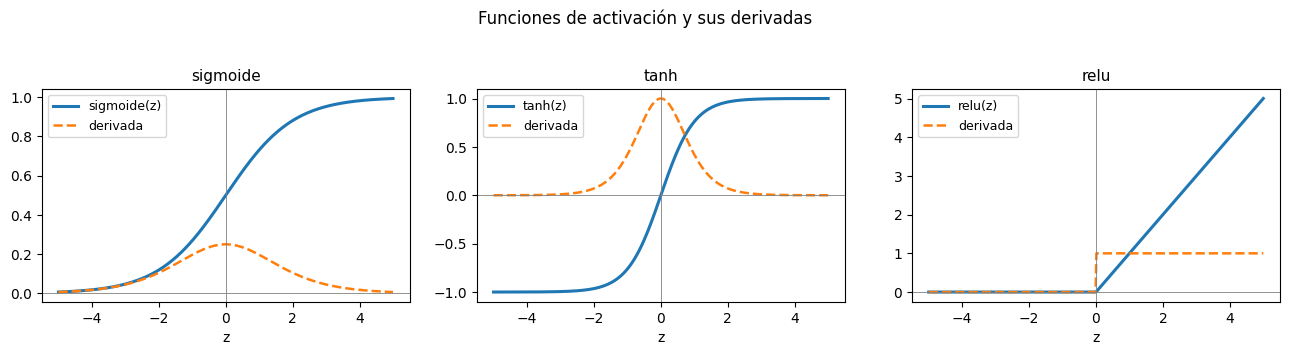

In [28]:
def sigmoide(z):
    """σ(z) = 1 / (1 + e^{-z}). Aplasta cualquier número real al intervalo (0, 1)."""
    # np.clip evita desbordamientos numéricos de exp() con valores muy grandes/pequeños
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def d_sigmoide(z):
    """σ'(z) = σ(z)·(1 − σ(z)). Máximo 0.25 en z = 0; casi cero en los extremos (saturación)."""
    s = sigmoide(z)
    return s * (1.0 - s)


def tanh(z):
    """tanh(z): como la sigmoide pero centrada en cero, con rango (−1, 1)."""
    return np.tanh(z)


def d_tanh(z):
    """tanh'(z) = 1 − tanh²(z). Máximo 1 en z = 0."""
    return 1.0 - np.tanh(z) ** 2


def relu(z):
    """ReLU(z) = max(0, z). Deja pasar lo positivo y anula lo negativo."""
    return np.maximum(0.0, z)


def d_relu(z):
    """ReLU'(z) = 1 si z > 0, si no 0. (En z = 0 se toma 0 por convención.)"""
    return (z > 0).astype(float)


# Diccionario nombre -> (función, derivada). La red lo usa para elegir su activación oculta.
ACTIVACIONES = {
    "sigmoide": (sigmoide, d_sigmoide),
    "tanh": (tanh, d_tanh),
    "relu": (relu, d_relu),
}

# --- Gráfica de cada activación junto con su derivada ---
z = np.linspace(-5, 5, 400)
fig, ejes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, (nombre, (g, dg)) in zip(ejes, ACTIVACIONES.items()):
    ax.plot(z, g(z), lw=2.2, label=f"{nombre}(z)")
    ax.plot(z, dg(z), lw=1.8, ls="--", label="derivada")
    ax.axhline(0, color="gray", lw=0.6)
    ax.axvline(0, color="gray", lw=0.6)
    ax.set_title(nombre)
    ax.set_xlabel("z")
    ax.legend(loc="upper left", fontsize=9)
fig.suptitle("Funciones de activación y sus derivadas", y=1.03)
plt.tight_layout()
plt.show()

**Observación:** la derivada de la sigmoide nunca supera 0.25 y se hace casi cero cuando $|z|$ es grande. Al multiplicar muchas de estas derivadas en la retropropagación, el gradiente se va encogiendo capa tras capa (**desvanecimiento del gradiente**). Por eso en las capas ocultas se prefieren `tanh` o `ReLU`, y la sigmoide se deja para la salida, donde necesitamos una probabilidad.

### Comprobación del ejemplo numérico de la sección 3.3.3

El mismo cálculo de la tabla hecho con NumPy: una sola multiplicación de matrices obtiene las 6 pre-activaciones a la vez.

In [29]:
# Comprobación del ejemplo numérico de la sección 3.3.3
A0 = np.array([[0.5, 1.0],
               [-1.0, 0.0]])            # 2 puntos (filas) × 2 coordenadas (columnas)
W1 = np.array([[1.0, -1.0],
               [0.5, 2.0],
               [-1.0, 0.0]])            # 3 neuronas (filas) × 2 entradas (columnas)
b1 = np.array([[0.0, 0.5, 1.0]])        # 1 sesgo por neurona

Z1 = A0 @ W1.T + b1                     # (2×2)·(2×3) + (1×3) → 2×3
A1 = np.tanh(Z1)                        # misma forma, activación elemento por elemento

print("Z1 =\n", Z1)
print("\nA1 = tanh(Z1) =\n", A1.round(3))

# La misma cuenta "a mano" para el punto 1 y la neurona 2 (producto punto + sesgo); debe dar 2.75:
print("\nz de la neurona 2 para el punto 1:", A0[0] @ W1[1] + b1[0, 1])

Z1 =
 [[-0.5   2.75  0.5 ]
 [-1.    0.    2.  ]]

A1 = tanh(Z1) =
 [[-0.462  0.992  0.462]
 [-0.762  0.     0.964]]

z de la neurona 2 para el punto 1: 2.75


### Comprobación del ejemplo numérico de la sección 3.5.6

Los ocho pasos de la retropropagación ejecutados con NumPy, con el mismo punto y los mismos pesos del ejemplo.

In [30]:
# Ejemplo de retropropagación paso a paso (sección 3.5.6), con una red 2 → 2 → 1.
# Las variables llevan el sufijo _ej para no interferir con los datos del anillo.
x_ej = np.array([[0.5, 1.0]])      # Un solo ejemplo (m = 1) con dos coordenadas
y_ej = np.array([[1.0]])           # Etiqueta real: el punto SÍ está en el anillo

W1_ej = np.array([[1.0, -1.0],     # Capa oculta: 2 neuronas (filas) × 2 entradas
                  [0.5,  2.0]])
b1_ej = np.array([[0.0, 0.5]])
W2_ej = np.array([[1.0, -2.0]])    # Capa de salida: 1 neurona × 2 entradas
b2_ej = np.array([[0.5]])

# --- Paso 1: hacia adelante (se guardan Z1 y A1 porque la vuelta los necesita) ---
Z1_ej = x_ej @ W1_ej.T + b1_ej
A1_ej = np.tanh(Z1_ej)
Z2_ej = A1_ej @ W2_ej.T + b2_ej
yhat_ej = sigmoide(Z2_ej)

# --- Paso 2: pérdida (entropía cruzada binaria) ---
perdida_ej = float(-(y_ej * np.log(yhat_ej) + (1 - y_ej) * np.log(1 - yhat_ej)).mean())
print(f"Paso 1  Z1 = {Z1_ej.round(4)}   A1 = tanh(Z1) = {A1_ej.round(4)}")
print(f"        z2 = {Z2_ej.round(4)}   ŷ = sigmoide(z2) = {yhat_ej.round(4)}")
print(f"Paso 2  pérdida = {perdida_ej:.4f}\n")

# --- Paso 3: gradiente en la salida. Con sigmoide + entropía cruzada se reduce a (ŷ − y) ---
dZ2_ej = yhat_ej - y_ej
print(f"Paso 3  dZ2 = ŷ − y = {dZ2_ej.round(4)}   (negativo: la red se quedó corta)")

# --- Paso 4: gradientes de la capa de salida = culpa × entrada ---
m_ej = x_ej.shape[0]
dW2_ej = (dZ2_ej.T @ A1_ej) / m_ej
db2_ej = dZ2_ej.mean(axis=0, keepdims=True)
print(f"Paso 4  dW2 = {dW2_ej.round(4)}   db2 = {db2_ej.round(4)}")

# --- Paso 5: repartir la culpa hacia la capa oculta, ponderada por los pesos ---
dA1_ej = dZ2_ej @ W2_ej
print(f"Paso 5  dA1 = dZ2 · W2 = {dA1_ej.round(4)}")

# --- Paso 6: convertir la culpa sobre 'a' en culpa sobre 'z' multiplicando por g'(z) ---
gprima_ej = 1 - np.tanh(Z1_ej) ** 2
dZ1_ej = dA1_ej * gprima_ej
print(f"Paso 6  g'(Z1) = {gprima_ej.round(4)}  →  dZ1 = dA1 * g'(Z1) = {dZ1_ej.round(4)}")
print(f"        la neurona 2 recibe {abs(dA1_ej[0, 1] / dA1_ej[0, 0]):.0f} veces más culpa, pero su "
      f"gradiente resulta {abs(dZ1_ej[0, 0] / dZ1_ej[0, 1]):.0f} veces menor: está saturada\n")

# --- Paso 7: gradientes de la capa oculta ---
dW1_ej = (dZ1_ej.T @ x_ej) / m_ej
db1_ej = dZ1_ej.mean(axis=0, keepdims=True)
print(f"Paso 7  dW1 =\n{dW1_ej.round(4)}\n        db1 = {db1_ej.round(4)}\n")

# --- Paso 8: actualizar los parámetros (W ← W − η·dW) y volver a evaluar el mismo punto ---
eta_ej = 0.1
W1_ej, b1_ej = W1_ej - eta_ej * dW1_ej, b1_ej - eta_ej * db1_ej
W2_ej, b2_ej = W2_ej - eta_ej * dW2_ej, b2_ej - eta_ej * db2_ej

yhat_nuevo_ej = sigmoide(np.tanh(x_ej @ W1_ej.T + b1_ej) @ W2_ej.T + b2_ej)
perdida_nueva_ej = float(-(y_ej * np.log(yhat_nuevo_ej) + (1 - y_ej) * np.log(1 - yhat_nuevo_ej)).mean())
print(f"Paso 8  W2 actualizado = {W2_ej.round(4)}")
print(f"        ŷ: {float(yhat_ej[0, 0]):.4f} → {float(yhat_nuevo_ej[0, 0]):.4f}     "
      f"pérdida: {perdida_ej:.4f} → {perdida_nueva_ej:.4f}   (mejoró en un solo paso)")

# --- Comprobación: ¿dW2[0,0] coincide con una derivada numérica? (idea de la sección 7) ---
def perdida_variando_w(valor):
    """Pérdida de la red original cuando W2[0,0] toma el valor indicado."""
    w2_prueba = np.array([[valor, -2.0]])
    p = sigmoide(A1_ej @ w2_prueba.T + np.array([[0.5]]))
    return float(-(y_ej * np.log(p) + (1 - y_ej) * np.log(1 - p)).mean())

eps_ej = 1e-6
numerico_ej = (perdida_variando_w(1.0 + eps_ej) - perdida_variando_w(1.0 - eps_ej)) / (2 * eps_ej)
print(f"\nComprobación de dW2[0,0]:  retropropagación = {dW2_ej[0, 0]:.6f}  |  numérico = {numerico_ej:.6f}")

Paso 1  Z1 = [[-0.5   2.75]]   A1 = tanh(Z1) = [[-0.4621  0.9919]]
        z2 = [[-1.9458]]   ŷ = sigmoide(z2) = [[0.125]]
Paso 2  pérdida = 2.0794

Paso 3  dZ2 = ŷ − y = [[-0.875]]   (negativo: la red se quedó corta)
Paso 4  dW2 = [[ 0.4043 -0.8679]]   db2 = [[-0.875]]
Paso 5  dA1 = dZ2 · W2 = [[-0.875  1.75 ]]
Paso 6  g'(Z1) = [[0.7864 0.0162]]  →  dZ1 = dA1 * g'(Z1) = [[-0.6881  0.0284]]
        la neurona 2 recibe 2 veces más culpa, pero su gradiente resulta 24 veces menor: está saturada

Paso 7  dW1 =
[[-0.3441 -0.6881]
 [ 0.0142  0.0284]]
        db1 = [[-0.6881  0.0284]]

Paso 8  W2 actualizado = [[ 0.9596 -1.9132]]
        ŷ: 0.1250 → 0.1640     pérdida: 2.0794 → 1.8078   (mejoró en un solo paso)

Comprobación de dW2[0,0]:  retropropagación = 0.404349  |  numérico = 0.404349


## 4. Generación del conjunto de datos (anillo / dona)

Generamos puntos **distribuidos uniformemente** dentro de un disco de radio `R_MAX`:

- **Ángulo** $\theta \sim \mathcal{U}(0, 2\pi)$.
- **Radio** $r = R_{max}\sqrt{u}$ con $u \sim \mathcal{U}(0,1)$. La raíz cuadrada es importante: el área de una corona crece con $r$, así que si tomáramos $r$ uniforme, los puntos se amontonarían en el centro. Con $\sqrt{u}$ la densidad por unidad de área es constante.
- Se pasa a cartesianas: $x_1 = r\cos\theta$, $x_2 = r\sin\theta$.
- La **etiqueta** se asigna con el radio *verdadero*: $y = 1$ si $R_1 \le r \le R_2$.
- Finalmente se suma **ruido gaussiano** a las coordenadas. Esto simula errores de medición: algunos puntos cercanos a la frontera quedan "del lado equivocado", como ocurre con datos reales, y evita que el problema sea artificialmente perfecto.

**Balance de clases:** con puntos uniformes en área, la proporción esperada de la clase 1 es el área del anillo entre el área del disco:
$$
\frac{\pi(R_2^2 - R_1^2)}{\pi R_{max}^2} = \frac{1.0^2 - 0.5^2}{1.3^2} \approx 0.44
$$
Es decir, ~44 % clase 1 y ~56 % clase 0: suficientemente balanceado. Este dato es importante: **un modelo que siempre responda "0" ya tendría ~56 % de exactitud**, así que cualquier resultado cercano a ese valor significa que el modelo no aprendió nada.

Forma de X: (1600, 2)   (1600 puntos, 2 características)
Forma de y: (1600,)
Clase 0 (fuera):   887 puntos (55.4%)
Clase 1 (anillo):  713 puntos (44.6%)

Primeros 5 ejemplos:
  x = (+0.184, -1.208)   radio = 1.222   y = 0
  x = (-0.487, +0.201)   radio = 0.527   y = 0
  x = (+0.708, -0.864)   radio = 1.117   y = 0
  x = (-0.378, -1.141)   radio = 1.202   y = 0
  x = (+0.497, +0.295)   radio = 0.578   y = 1


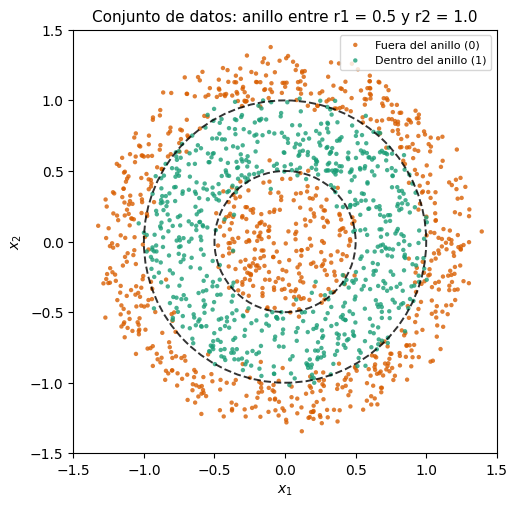

In [31]:
def generar_anillo(n=1600, r1=R1, r2=R2, r_max=R_MAX, ruido=0.05, semilla=SEMILLA):
    """
    Genera n puntos 2D uniformes en un disco y los etiqueta según si caen en el anillo.

    Parámetros
    ----------
    n      : número de puntos a generar.
    r1, r2 : radio interior y exterior del anillo (clase 1).
    r_max  : radio máximo del disco donde se generan los puntos.
    ruido  : desviación estándar del ruido gaussiano sumado a las coordenadas.
    semilla: semilla del generador aleatorio (reproducibilidad).

    Regresa
    -------
    X : arreglo (n, 2) con las coordenadas (x1, x2).
    y : arreglo (n,) con etiquetas 0/1.
    """
    rng = np.random.default_rng(semilla)          # Generador aleatorio independiente y reproducible

    theta = rng.uniform(0.0, 2.0 * np.pi, n)       # Ángulo uniforme en [0, 2π)
    r = r_max * np.sqrt(rng.uniform(0.0, 1.0, n))  # Radio con √u → densidad uniforme por área

    X = np.column_stack([r * np.cos(theta),        # Coordenada x1
                         r * np.sin(theta)])       # Coordenada x2

    y = ((r >= r1) & (r <= r2)).astype(int)        # Etiqueta con el radio real: 1 si está en el anillo

    X = X + rng.normal(0.0, ruido, size=X.shape)   # Ruido de "medición" sobre las coordenadas
    return X, y


def dibujar_circulos(ax, r1=R1, r2=R2):
    """Dibuja las dos circunferencias que definen la frontera REAL del anillo."""
    for radio in (r1, r2):
        ax.add_patch(Circle((0, 0), radio, fill=False, ls="--", lw=1.4, ec="black", alpha=0.8))


def graficar_datos(ax, X, y, titulo=""):
    """Diagrama de dispersión de los puntos coloreados por clase + circunferencias reales."""
    for clase in (0, 1):
        m = y == clase
        ax.scatter(X[m, 0], X[m, 1], s=10, c=COLOR_CLASE[clase], label=NOMBRE_CLASE[clase],
                   alpha=0.8, edgecolors="none")
    dibujar_circulos(ax)
    ax.set_aspect("equal")                  # Misma escala en ambos ejes (si no, el círculo se ve ovalado)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(titulo)


# --- Generación del conjunto principal ---
X, y = generar_anillo(n=1600, ruido=0.05)

print(f"Forma de X: {X.shape}   (1600 puntos, 2 características)")
print(f"Forma de y: {y.shape}")
print(f"Clase 0 (fuera):  {np.sum(y == 0):4d} puntos ({np.mean(y == 0):.1%})")
print(f"Clase 1 (anillo): {np.sum(y == 1):4d} puntos ({np.mean(y == 1):.1%})")
print("\nPrimeros 5 ejemplos:")
for i in range(5):
    print(f"  x = ({X[i, 0]:+.3f}, {X[i, 1]:+.3f})   radio = {np.hypot(*X[i]):.3f}   y = {y[i]}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
graficar_datos(ax, X, y, "Conjunto de datos: anillo entre r1 = 0.5 y r2 = 1.0")
ax.legend(loc="upper right", fontsize=8)
plt.show()

Las líneas punteadas son la frontera **real**. Los puntos verdes forman la dona; los naranjas están en el centro o afuera. Nótese que por el ruido hay algunos puntos mezclados cerca de las circunferencias: ni siquiera un clasificador perfecto con la regla del radio llegaría al 100 % en estos datos.

Es evidente a simple vista que **ninguna recta** puede separar el verde del naranja.

## 5. Preprocesamiento

### 5.1 División entrenamiento / prueba

Separamos los datos en:
- **Entrenamiento (75 %)**: la red ajusta sus pesos con estos datos.
- **Prueba (25 %)**: la red **nunca** los ve durante el entrenamiento. Sirven para medir si la red *generaliza* (aprendió la forma del anillo) o solo *memorizó* los puntos de entrenamiento.

Usamos `stratify=y` para que ambos subconjuntos conserven la misma proporción de clases.

### 5.2 Estandarización

Transformamos cada característica para que tenga media 0 y desviación estándar 1:
$$
x' = \frac{x - \mu}{\sigma}
$$

¿Por qué?
- Las activaciones como `tanh` son más sensibles alrededor de 0; si las entradas son muy grandes, las neuronas se **saturan** (derivada ≈ 0) y dejan de aprender.
- Con características en escalas parecidas, el descenso de gradiente avanza de forma más uniforme en todas las direcciones.

**Regla de oro:** $\mu$ y $\sigma$ se calculan **solo con el conjunto de entrenamiento** y luego se aplican a prueba. Si usáramos los datos de prueba para calcularlas, se "filtraría" información del futuro al modelo (*data leakage*).

En este problema los datos ya están casi centrados, así que el efecto es pequeño; aun así se incluye porque es una buena práctica indispensable en problemas reales.

In [32]:
class Estandarizador:
    """Estandarización z-score implementada a mano: x' = (x − μ) / σ."""

    def ajustar(self, X):
        # Se "aprenden" media y desviación de cada columna SOLO con datos de entrenamiento
        self.media = X.mean(axis=0)
        self.desv = X.std(axis=0)
        return self

    def transformar(self, X):
        # Se aplica la misma transformación a cualquier conjunto (entrenamiento, prueba, puntos nuevos)
        return (X - self.media) / self.desv


# División estratificada 75 % / 25 %
X_ent, X_pru, y_ent, y_pru = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEMILLA
)

# Ajuste del estandarizador con entrenamiento y aplicación a ambos conjuntos
escalador = Estandarizador().ajustar(X_ent)
X_ent_s = escalador.transformar(X_ent)
X_pru_s = escalador.transformar(X_pru)

# La red trabaja con etiquetas como vector columna (m, 1) para que coincida con la forma de su salida
Y_ent = y_ent.reshape(-1, 1)
Y_pru = y_pru.reshape(-1, 1)

print(f"Entrenamiento: {X_ent.shape[0]} puntos  | proporción clase 1 = {y_ent.mean():.3f}")
print(f"Prueba:        {X_pru.shape[0]} puntos  | proporción clase 1 = {y_pru.mean():.3f}")
print(f"\nμ (entrenamiento)          = {escalador.media.round(4)}")
print(f"σ (entrenamiento)          = {escalador.desv.round(4)}")
print(f"Media tras estandarizar    = {X_ent_s.mean(axis=0).round(4)}")
print(f"Desv. tras estandarizar    = {X_ent_s.std(axis=0).round(4)}")

Entrenamiento: 1200 puntos  | proporción clase 1 = 0.446
Prueba:        400 puntos  | proporción clase 1 = 0.445

μ (entrenamiento)          = [0.0316 0.0166]
σ (entrenamiento)          = [0.6544 0.6515]
Media tras estandarizar    = [ 0. -0.]
Desv. tras estandarizar    = [1. 1.]


## 6. Implementación de la red neuronal desde cero con NumPy

La clase `RedNeuronal` implementa un perceptrón multicapa totalmente conectado para clasificación binaria. Su arquitectura se define con una lista de tamaños de capa. Por ejemplo `[2, 8, 8, 1]` significa:

```
 entrada (2)  →  oculta 1 (8 neuronas)  →  oculta 2 (8 neuronas)  →  salida (1 neurona, sigmoide)
   x1, x2          activación tanh            activación tanh          P(y = 1 | x)
```

El número de parámetros aprendibles es $\sum_l (n_{l-1} \cdot n_l + n_l)$; para `[2, 8, 8, 1]` son $(2\cdot8+8) + (8\cdot8+8) + (8\cdot1+1) = 24 + 72 + 9 = 105$.

### Inicialización de los pesos

Los pesos **no** pueden empezar en cero: si todas las neuronas de una capa empiezan iguales, reciben el mismo gradiente y seguirán siendo idénticas para siempre (problema de **simetría**). Se inicializan aleatoriamente, pero con una escala cuidadosa para que las señales no se hagan ni enormes ni diminutas al atravesar las capas:

- **Xavier/Glorot** (para `tanh` y `sigmoide`): $W \sim \mathcal{N}\!\left(0, \frac{2}{n_{ent} + n_{sal}}\right)$ — Glorot y Bengio (2010).
- **He** (para `ReLU`): $W \sim \mathcal{N}\!\left(0, \frac{2}{n_{ent}}\right)$ — compensa que ReLU anula la mitad de las señales. He et al. (2015).

Los sesgos sí pueden empezar en cero, porque la aleatoriedad de los pesos ya rompe la simetría.

### Métodos de la clase

| Método | Qué hace | Sección teórica |
|---|---|---|
| `__init__` | Crea e inicializa pesos y sesgos | 6 (inicialización) |
| `_forward` | Propagación hacia adelante; guarda $Z$ y $A$ de cada capa | 3.3 |
| `_perdida` | Entropía cruzada binaria | 3.4 |
| `_backward` | Retropropagación: gradientes de todos los parámetros | 3.5 |
| `_actualizar` | Paso de descenso de gradiente | 3.6 |
| `entrenar` | Ciclo completo por épocas y mini-lotes con decaimiento de $\eta$; registra el historial | 3.6, 3.7 |
| `predecir_proba` / `predecir` | Probabilidad de clase 1 / clase final (umbral 0.5) | — |

In [33]:
class RedNeuronal:
    """
    Perceptrón multicapa para clasificación binaria, implementado solo con NumPy.

    - Capas ocultas con activación configurable ('tanh', 'relu' o 'sigmoide').
    - Capa de salida con 1 neurona y activación sigmoide → probabilidad P(y=1 | x).
    - Pérdida: entropía cruzada binaria.
    - Optimización: descenso de gradiente por mini-lotes.
    """

    def __init__(self, capas, activacion="tanh", tasa_aprendizaje=0.1, decaimiento=0.0, semilla=SEMILLA):
        # capas: lista con el número de neuronas por capa, incluyendo entrada y salida. Ej. [2, 8, 8, 1]
        self.capas = list(capas)
        self.L = len(self.capas) - 1                     # Número de capas con pesos (sin contar la entrada)
        self.activacion = activacion
        self.g, self.dg = ACTIVACIONES[activacion]       # Función de activación oculta y su derivada
        self.eta0 = tasa_aprendizaje                     # η₀: tasa de aprendizaje inicial
        self.eta = tasa_aprendizaje                      # η actual (cambia si hay decaimiento)
        self.decaimiento = decaimiento                   # δ en η_t = η₀ / (1 + δ·t)
        self.rng = np.random.default_rng(semilla)        # Generador propio → resultados reproducibles

        self.W = []   # W[l] tiene forma (neuronas de la capa l+1, neuronas de la capa l)
        self.b = []   # b[l] tiene forma (1, neuronas de la capa l+1)
        for l in range(self.L):
            n_ent, n_sal = self.capas[l], self.capas[l + 1]
            es_oculta = l < self.L - 1
            if activacion == "relu" and es_oculta:
                desv = np.sqrt(2.0 / n_ent)              # Inicialización He
            else:
                desv = np.sqrt(2.0 / (n_ent + n_sal))    # Inicialización Xavier/Glorot
            self.W.append(self.rng.normal(0.0, desv, size=(n_sal, n_ent)))
            self.b.append(np.zeros((1, n_sal)))          # Sesgos en cero

        # Historial del entrenamiento (una entrada por época)
        self.historial = {"perdida_ent": [], "perdida_val": [], "exact_ent": [], "exact_val": []}
        self.epocas_entrenadas = 0

    # ------------------------------------------------------------------ #
    def n_parametros(self):
        """Total de pesos y sesgos aprendibles."""
        return sum(W.size + b.size for W, b in zip(self.W, self.b))

    # ------------------------------------------------------------------ #
    def _forward(self, X):
        """
        Propagación hacia adelante.
        Regresa la salida de la red (probabilidades, forma (m, 1)) y un 'cache' con
        los valores intermedios Z y A de cada capa, que la retropropagación necesita.
        """
        A = X                               # A[0] = entradas
        cache = {"A": [A], "Z": []}
        for l in range(self.L):
            Z = A @ self.W[l].T + self.b[l]     # Combinación lineal de TODAS las neuronas de la capa a la vez
            if l == self.L - 1:
                A = sigmoide(Z)                 # Capa de salida → probabilidad
            else:
                A = self.g(Z)                   # Capa oculta → activación no lineal
            cache["Z"].append(Z)
            cache["A"].append(A)
        return A, cache

    # ------------------------------------------------------------------ #
    @staticmethod
    def _perdida(Y, y_hat):
        """Entropía cruzada binaria promedio."""
        eps = 1e-12
        y_hat = np.clip(y_hat, eps, 1.0 - eps)  # Evita log(0) = −∞ si la red está "demasiado segura"
        return float(-np.mean(Y * np.log(y_hat) + (1.0 - Y) * np.log(1.0 - y_hat)))

    # ------------------------------------------------------------------ #
    def _backward(self, cache, Y):
        """
        Retropropagación: calcula ∂L/∂W y ∂L/∂b para todas las capas,
        recorriendo la red desde la salida hacia la entrada (regla de la cadena).
        """
        m = Y.shape[0]
        grad_w = [None] * self.L
        grad_b = [None] * self.L

        # Capa de salida: con sigmoide + entropía cruzada, dL/dz se reduce a (ŷ − y)
        dz = cache["A"][-1] - Y

        for l in reversed(range(self.L)):
            a_prev = cache["A"][l]                          # Entrada que recibió la capa l
            grad_w[l] = (dz.T @ a_prev) / m                 # dW = dzᵀ·a_prev / m
            grad_b[l] = dz.mean(axis=0, keepdims=True)      # db = promedio de dz
            if l > 0:
                da_prev = dz @ self.W[l]                    # El error viaja hacia atrás por los pesos
                dz = da_prev * self.dg(cache["Z"][l - 1])   # ...y se escala por la sensibilidad g'(Z)
        return grad_w, grad_b

    # ------------------------------------------------------------------ #
    def _actualizar(self, grad_w, grad_b):
        """Un paso de descenso de gradiente: parámetro ← parámetro − η · gradiente."""
        for l in range(self.L):
            self.W[l] -= self.eta * grad_w[l]
            self.b[l] -= self.eta * grad_b[l]

    # ------------------------------------------------------------------ #
    def entrenar(self, X, Y, epocas=300, tam_lote=32, x_val=None, y_val=None, imprimir_cada=0):
        """
        Entrena la red con descenso de gradiente por mini-lotes.
        Puede llamarse varias veces: el entrenamiento continúa desde donde se quedó.
        """
        m = X.shape[0]
        for _ in range(epocas):
            # 0) Tasa de aprendizaje de esta época: η_t = η₀ / (1 + δ·t). Si δ = 0, η se mantiene constante.
            self.eta = self.eta0 / (1.0 + self.decaimiento * self.epocas_entrenadas)

            # 1) Barajar: evita que la red vea siempre los ejemplos en el mismo orden
            indices = self.rng.permutation(m)

            # 2) Recorrer los datos en mini-lotes
            for inicio in range(0, m, tam_lote):
                lote = indices[inicio:inicio + tam_lote]
                y_hat, cache = self._forward(X[lote])          # Forward
                grad_w, grad_b = self._backward(cache, Y[lote]) # Backward
                self._actualizar(grad_w, grad_b)                # Actualización

            # 3) Al terminar la época, medir desempeño en todo el conjunto (sin actualizar pesos)
            self.epocas_entrenadas += 1
            p_ent = self.predecir_proba(X)
            self.historial["perdida_ent"].append(self._perdida(Y, p_ent))
            self.historial["exact_ent"].append(float(np.mean((p_ent >= 0.5) == Y)))
            if x_val is not None:
                p_val = self.predecir_proba(x_val)
                self.historial["perdida_val"].append(self._perdida(y_val, p_val))
                self.historial["exact_val"].append(float(np.mean((p_val >= 0.5) == y_val)))

            if imprimir_cada and self.epocas_entrenadas % imprimir_cada == 0:
                msg = (f"Época {self.epocas_entrenadas:4d} | pérdida ent = {self.historial['perdida_ent'][-1]:.4f}"
                       f" | exactitud ent = {self.historial['exact_ent'][-1]:.3f}")
                if x_val is not None:
                    msg += (f" | pérdida prueba = {self.historial['perdida_val'][-1]:.4f}"
                            f" | exactitud prueba = {self.historial['exact_val'][-1]:.3f}")
                print(msg)
        return self

    # ------------------------------------------------------------------ #
    def predecir_proba(self, X):
        """Probabilidad de que cada punto pertenezca a la clase 1 (anillo). Forma (m, 1)."""
        return self._forward(X)[0]

    def predecir(self, X):
        """Clase final: 1 si la probabilidad es ≥ 0.5, si no 0. Forma (m,)."""
        return (self.predecir_proba(X) >= 0.5).astype(int).ravel()

    def __repr__(self):
        return (f"RedNeuronal(capas={self.capas}, activacion='{self.activacion}', "
                f"eta0={self.eta0}, decaimiento={self.decaimiento}, parámetros={self.n_parametros()})")


red_demo = RedNeuronal([2, 8, 8, 1])
print(red_demo)
for l, (W, b) in enumerate(zip(red_demo.W, red_demo.b), start=1):
    print(f"  Capa {l}: W{W.shape}  b{b.shape}")

RedNeuronal(capas=[2, 8, 8, 1], activacion='tanh', eta0=0.1, decaimiento=0.0, parámetros=105)
  Capa 1: W(8, 2)  b(1, 8)
  Capa 2: W(8, 8)  b(1, 8)
  Capa 3: W(1, 8)  b(1, 1)


## 7. Verificación numérica de los gradientes

La retropropagación es la parte más propensa a errores: un signo o una transposición equivocada y la red "aprende" mal sin que haya ningún mensaje de error. Para asegurarnos de que las fórmulas están bien implementadas usamos **verificación de gradientes** (*gradient checking*).

La idea: la derivada puede aproximarse con **diferencias finitas centradas**, moviendo un solo peso un poquito $\varepsilon$ hacia arriba y hacia abajo:
$$
\frac{\partial \mathcal{L}}{\partial w} \approx \frac{\mathcal{L}(w + \varepsilon) - \mathcal{L}(w - \varepsilon)}{2\varepsilon}
$$
Esto es lentísimo (dos forwards por cada parámetro), pero no depende de nuestras fórmulas. Si el gradiente analítico (backprop) y el numérico coinciden, la implementación es correcta. Se compara con el **error relativo**:
$$
\text{error} = \frac{\lVert g_{\text{backprop}} - g_{\text{numérico}} \rVert}{\lVert g_{\text{backprop}} \rVert + \lVert g_{\text{numérico}} \rVert}
$$
Valores menores a $10^{-7}$ indican que todo está bien.

In [34]:
def verificar_gradientes(red, X, Y, eps=1e-5):
    """Compara los gradientes de backprop contra diferencias finitas centradas."""
    # Gradiente analítico (retropropagación)
    _, cache = red._forward(X)
    grad_w, grad_b = red._backward(cache, Y)
    analitico = np.concatenate([g.ravel() for par in zip(grad_w, grad_b) for g in par])

    # Gradiente numérico: se perturba cada parámetro individualmente
    numerico = []
    for l in range(red.L):
        for P in (red.W[l], red.b[l]):          # Primero pesos, luego sesgos (mismo orden que arriba)
            for idx in np.ndindex(P.shape):
                original = P[idx]
                P[idx] = original + eps
                perdida_mas = red._perdida(Y, red.predecir_proba(X))
                P[idx] = original - eps
                perdida_menos = red._perdida(Y, red.predecir_proba(X))
                P[idx] = original                # Restaurar el valor
                numerico.append((perdida_mas - perdida_menos) / (2 * eps))
    numerico = np.array(numerico)

    error = np.linalg.norm(analitico - numerico) / (np.linalg.norm(analitico) + np.linalg.norm(numerico))
    return error, analitico, numerico


for act in ("tanh", "sigmoide", "relu"):
    red_chica = RedNeuronal([2, 4, 3, 1], activacion=act, semilla=0)
    error, g_a, g_n = verificar_gradientes(red_chica, X_ent_s[:30], Y_ent[:30])
    estado = "OK" if error < 1e-7 else "REVISAR"
    print(f"Activación {act:9s} | {g_a.size} parámetros | error relativo = {error:.2e}  → {estado}")

print("\nPrimeros 6 gradientes (tanh):")
red_chica = RedNeuronal([2, 4, 3, 1], activacion="tanh", semilla=0)
_, g_a, g_n = verificar_gradientes(red_chica, X_ent_s[:30], Y_ent[:30])
for a, n in zip(g_a[:6], g_n[:6]):
    print(f"  backprop = {a:+.8f}   numérico = {n:+.8f}")

Activación tanh      | 31 parámetros | error relativo = 1.08e-10  → OK
Activación sigmoide  | 31 parámetros | error relativo = 2.23e-10  → OK
Activación relu      | 31 parámetros | error relativo = 2.41e-10  → OK

Primeros 6 gradientes (tanh):
  backprop = +0.04726132   numérico = +0.04726132
  backprop = +0.08584731   numérico = +0.08584731
  backprop = -0.00121855   numérico = -0.00121855
  backprop = -0.00194373   numérico = -0.00194373
  backprop = +0.03797359   numérico = +0.03797359
  backprop = +0.05981894   numérico = +0.05981894


Los gradientes calculados por retropropagación coinciden con los numéricos hasta muchos decimales para las tres activaciones. Con esto tenemos la confianza de que la implementación de la sección 6 es matemáticamente correcta.

> Con ReLU el error puede ser ligeramente mayor porque su derivada es discontinua en $z = 0$; si algún punto cae justo ahí, la diferencia finita "cruza" el quiebre. Sigue siendo despreciable.

## 8. Experimento 1: modelo **sin** capa oculta

Antes de construir la red profunda, probemos lo más simple: una sola neurona con sigmoide, arquitectura `[2, 1]`. Esto es exactamente una **regresión logística** (y equivale a un perceptrón con salida probabilística).

Como vimos en la teoría, su frontera de decisión $w_1 x_1 + w_2 x_2 + b = 0$ es **una recta**. Predicción: fracasará, con una exactitud cercana al 56 % de "responder siempre la clase mayoritaria".

Primero definimos una función para dibujar la **frontera de decisión** de cualquier modelo, que usaremos durante el resto de la práctica:

1. Se crea una malla fina de puntos que cubre todo el plano.
2. Se estandarizan con el mismo `escalador` de los datos de entrenamiento.
3. El modelo predice la probabilidad de clase 1 en cada punto de la malla.
4. Se colorea el fondo según esa probabilidad (naranja ≈ 0, verde ≈ 1) y se dibuja en negro la curva donde la probabilidad es exactamente 0.5: **esa curva es la frontera de decisión**.

RedNeuronal(capas=[2, 1], activacion='tanh', eta0=0.1, decaimiento=0.0, parámetros=3)
Pesos aprendidos: w = [-0.0069  0.0602],  b = [-0.2049]
Exactitud en prueba:                       0.555
Exactitud de 'siempre la clase mayoritaria': 0.555


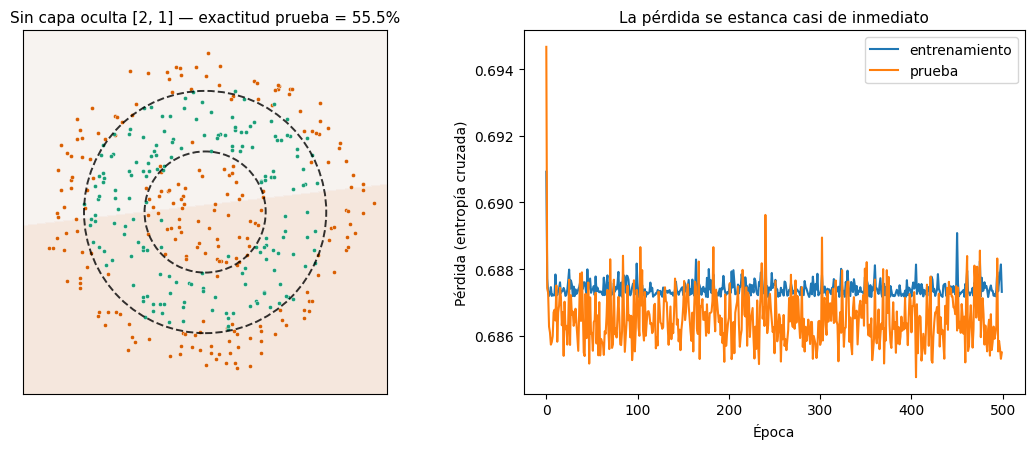

In [35]:
def probabilidad_en_malla(modelo, resolucion=250, limite=1.5):
    """Evalúa P(y=1) del modelo en una malla regular del plano (en coordenadas originales)."""
    ejes = np.linspace(-limite, limite, resolucion)
    xx, yy = np.meshgrid(ejes, ejes)
    puntos = np.column_stack([xx.ravel(), yy.ravel()])     # (resolucion², 2)
    puntos_s = escalador.transformar(puntos)               # ¡Misma estandarización que en entrenamiento!
    if hasattr(modelo, "predecir_proba"):                   # Nuestra red
        P = modelo.predecir_proba(puntos_s).ravel()
    else:                                                    # Modelos de scikit-learn
        P = modelo.predict_proba(puntos_s)[:, 1]
    return xx, yy, P.reshape(xx.shape)


# Mapa de colores naranja (clase 0) → blanco → verde (clase 1)
MAPA = matplotlib.colors.LinearSegmentedColormap.from_list(
    "anillo", [COLOR_CLASE[0], "#f7f7f7", COLOR_CLASE[1]]
)


def graficar_frontera(ax, modelo, x_orig, y_orig, titulo="", mostrar_puntos=True):
    """Fondo = probabilidad predicha; línea negra = frontera (P = 0.5); punteado = anillo real."""
    xx, yy, P = probabilidad_en_malla(modelo)
    ax.contourf(xx, yy, P, levels=np.linspace(0, 1, 21), cmap=MAPA, alpha=0.75)
    ax.contour(xx, yy, P, levels=[0.5], colors="black", linewidths=2)
    if mostrar_puntos:
        for clase in (0, 1):
            m = y_orig == clase
            ax.scatter(x_orig[m, 0], x_orig[m, 1], s=9, c=COLOR_CLASE[clase],
                       edgecolors="white", linewidths=0.3)
    dibujar_circulos(ax)
    ax.set_aspect("equal")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(titulo)


# --- Entrenamiento del modelo lineal ---
modelo_lineal = RedNeuronal([2, 1], tasa_aprendizaje=0.1)
modelo_lineal.entrenar(X_ent_s, Y_ent, epocas=500, tam_lote=16, x_val=X_pru_s, y_val=Y_pru)

exact_lineal = accuracy_score(y_pru, modelo_lineal.predecir(X_pru_s))
mayoritaria = max(np.mean(y_pru), 1 - np.mean(y_pru))
print(modelo_lineal)
print(f"Pesos aprendidos: w = {modelo_lineal.W[0].ravel().round(4)},  b = {modelo_lineal.b[0].ravel().round(4)}")
print(f"Exactitud en prueba:                       {exact_lineal:.3f}")
print(f"Exactitud de 'siempre la clase mayoritaria': {mayoritaria:.3f}")

fig, ejes = plt.subplots(1, 2, figsize=(11, 4.6))
graficar_frontera(ejes[0], modelo_lineal, X_pru, y_pru,
                  f"Sin capa oculta [2, 1] — exactitud prueba = {exact_lineal:.1%}")
ejes[1].plot(modelo_lineal.historial["perdida_ent"], label="entrenamiento")
ejes[1].plot(modelo_lineal.historial["perdida_val"], label="prueba")
ejes[1].set_xlabel("Época")
ejes[1].set_ylabel("Pérdida (entropía cruzada)")
ejes[1].set_title("La pérdida se estanca casi de inmediato")
ejes[1].legend()
plt.tight_layout()
plt.show()

**Resultado:** tal como predijo la teoría, el modelo sin capa oculta es incapaz de resolver el problema:

- Su exactitud es **exactamente** la de responder siempre la clase mayoritaria ("fuera del anillo").
- En la gráfica **no aparece la línea negra** de frontera: la probabilidad predicha nunca llega a 0.5 en ninguna parte del plano, así que el modelo responde "0" para todos los puntos.
- La pérdida cae en las primeras épocas y se estanca en ≈ 0.687. Ese valor no es casualidad: es la entropía de la proporción de clases, $-(0.446\ln 0.446 + 0.554\ln 0.554) \approx 0.687$, que es la pérdida de un modelo que ignora la entrada y siempre responde "44.6 % de probabilidad de anillo".
- Los pesos aprendidos $w \approx (-0.01, 0.06)$ son prácticamente cero: el modelo "descubrió" que **ninguna inclinación de la recta ayuda** y solo ajustó el sesgo $b$ a la proporción de clases ($\sigma(-0.205) \approx 0.45$).

El modelo no está "mal entrenado": **la mejor recta posible sigue siendo inútil**. Es la misma lección de XOR: hace falta al menos una capa oculta.

## 9. Experimento 2: red neuronal multicapa

### Diseño y justificación de los hiperparámetros

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| Arquitectura | `[2, 8, 8, 1]` | 2 entradas $(x_1, x_2)$; dos capas ocultas de 8 neuronas dan margen de sobra para formar la doble frontera circular (la sección 11 muestra cuántas hacen falta realmente); 1 salida con probabilidad |
| Activación oculta | `tanh` | Centrada en cero, suave y con buen gradiente; en redes tan pequeñas funciona mejor que ReLU (que puede dejar neuronas "muertas") |
| Activación salida | sigmoide | Probabilidad en $(0,1)$ para clasificación binaria |
| Inicialización | Xavier/Glorot | Adecuada para `tanh` |
| Pérdida | Entropía cruzada binaria | Estándar para clasificación binaria; gradiente simple $\hat{y}-y$ |
| Tasa de aprendizaje inicial $\eta_0$ | 0.1 | Valor intermedio; la sección 11 compara con otros |
| Decaimiento $\delta$ | 0.01 | En la época 500, $\eta = 0.1/6 \approx 0.017$: pasos grandes al inicio, finos al final. Sin decaimiento la exactitud en prueba oscilaba varios puntos entre épocas |
| Tamaño de lote | 16 | Lotes pequeños → muchas actualizaciones por época (75) |
| Épocas | 500 | Suficientes para que la pérdida se estabilice (ver curvas) |

La red tiene **105 parámetros** para 1 200 ejemplos de entrenamiento, así que no hay mucho riesgo de sobreajuste.

In [36]:
red = RedNeuronal([2, 8, 8, 1], activacion="tanh", tasa_aprendizaje=0.1, decaimiento=0.01, semilla=SEMILLA)
print(red, "\n")

inicio = time.perf_counter()
red.entrenar(X_ent_s, Y_ent, epocas=500, tam_lote=16,
             x_val=X_pru_s, y_val=Y_pru, imprimir_cada=50)
print(f"\nTiempo de entrenamiento: {time.perf_counter() - inicio:.2f} s")

RedNeuronal(capas=[2, 8, 8, 1], activacion='tanh', eta0=0.1, decaimiento=0.01, parámetros=105) 

Época   50 | pérdida ent = 0.5650 | exactitud ent = 0.767 | pérdida prueba = 0.5935 | exactitud prueba = 0.710
Época  100 | pérdida ent = 0.2352 | exactitud ent = 0.919 | pérdida prueba = 0.2931 | exactitud prueba = 0.885
Época  150 | pérdida ent = 0.2105 | exactitud ent = 0.914 | pérdida prueba = 0.2633 | exactitud prueba = 0.885
Época  200 | pérdida ent = 0.1819 | exactitud ent = 0.931 | pérdida prueba = 0.2314 | exactitud prueba = 0.905
Época  250 | pérdida ent = 0.1766 | exactitud ent = 0.928 | pérdida prueba = 0.2320 | exactitud prueba = 0.892
Época  300 | pérdida ent = 0.1825 | exactitud ent = 0.935 | pérdida prueba = 0.2504 | exactitud prueba = 0.905
Época  350 | pérdida ent = 0.1723 | exactitud ent = 0.930 | pérdida prueba = 0.2270 | exactitud prueba = 0.902
Época  400 | pérdida ent = 0.1666 | exactitud ent = 0.931 | pérdida prueba = 0.2207 | exactitud prueba = 0.902
Época  450 | pé

## 10. Análisis de resultados y visualización de lo aprendido

### 10.1 Curvas de aprendizaje

Muestran cómo evolucionan la pérdida y la exactitud época tras época. Lo que buscamos:
- Que la pérdida **baje** y se estabilice.
- Que las curvas de entrenamiento y prueba estén **cerca** entre sí. Si la de entrenamiento siguiera bajando mientras la de prueba sube, sería señal de **sobreajuste** (memorización).

**¿Cuál es la mejor exactitud posible?** Como los puntos tienen ruido, ni siquiera la regla *verdadera* ($r_1 \le r \le r_2$ aplicada a las coordenadas observadas) acierta en todos. Calcular su exactitud nos da un **techo de referencia**: si la red se acerca a ese valor, ya aprendió prácticamente todo lo que los datos permiten aprender.

Exactitud de la regla ideal (techo) → entrenamiento: 0.937 | prueba: 0.910



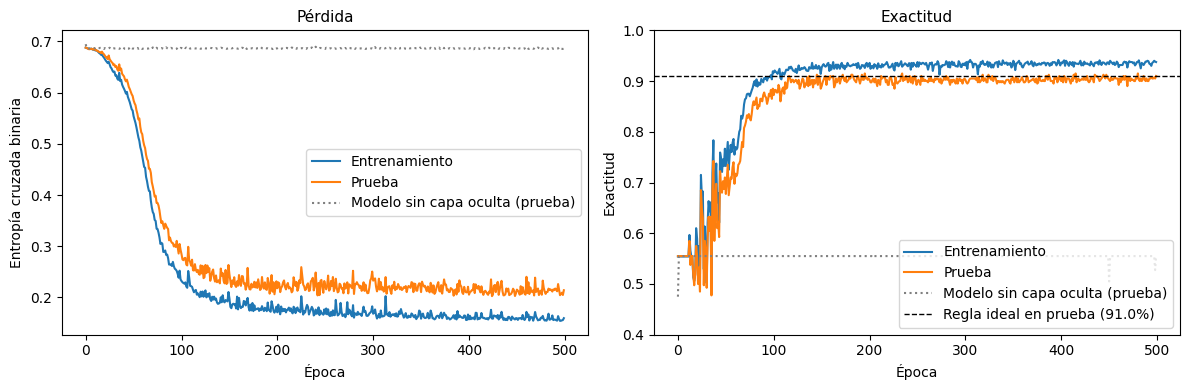

Pérdida final   → entrenamiento: 0.1594 | prueba: 0.2140
Exactitud final → entrenamiento: 0.938  | prueba: 0.910


In [37]:
def regla_ideal(x_orig):
    """Clasificador 'perfecto' que conoce la regla real: usa el radio de las coordenadas observadas."""
    r = np.hypot(x_orig[:, 0], x_orig[:, 1])
    return ((r >= R1) & (r <= R2)).astype(int)

techo_ent = accuracy_score(y_ent, regla_ideal(X_ent))
techo_pru = accuracy_score(y_pru, regla_ideal(X_pru))
print(f"Exactitud de la regla ideal (techo) → entrenamiento: {techo_ent:.3f} | prueba: {techo_pru:.3f}\n")

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

ejes[0].plot(red.historial["perdida_ent"], label="Entrenamiento")
ejes[0].plot(red.historial["perdida_val"], label="Prueba")
ejes[0].plot(modelo_lineal.historial["perdida_val"], ls=":", c="gray", label="Modelo sin capa oculta (prueba)")
ejes[0].set_xlabel("Época")
ejes[0].set_ylabel("Entropía cruzada binaria")
ejes[0].set_title("Pérdida")
ejes[0].legend()

ejes[1].plot(red.historial["exact_ent"], label="Entrenamiento")
ejes[1].plot(red.historial["exact_val"], label="Prueba")
ejes[1].plot(modelo_lineal.historial["exact_val"], ls=":", c="gray", label="Modelo sin capa oculta (prueba)")
ejes[1].axhline(techo_pru, c="black", ls="--", lw=1, label=f"Regla ideal en prueba ({techo_pru:.1%})")
ejes[1].set_xlabel("Época")
ejes[1].set_ylabel("Exactitud")
ejes[1].set_title("Exactitud")
ejes[1].set_ylim(0.4, 1.0)
ejes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"Pérdida final   → entrenamiento: {red.historial['perdida_ent'][-1]:.4f} | prueba: {red.historial['perdida_val'][-1]:.4f}")
print(f"Exactitud final → entrenamiento: {red.historial['exact_ent'][-1]:.3f}  | prueba: {red.historial['exact_val'][-1]:.3f}")

**Lectura de las curvas:**
- Durante las primeras ~40 épocas la pérdida baja lentamente y la exactitud oscila alrededor de la clase mayoritaria: la red está en una **meseta** (*plateau*), reorganizando pesos sin que todavía se note en las predicciones.
- Entre las épocas ~40 y ~100 ocurre la caída brusca de la pérdida: la red "encuentra" la estructura del anillo.
- Después, las curvas se estabilizan. La exactitud en prueba se pega a la línea punteada de la **regla ideal**: la red alcanzó prácticamente el máximo que permite el ruido de los datos.
- La brecha entre entrenamiento y prueba es pequeña y estable (no crece), así que **no hay sobreajuste** relevante. Parte de esa brecha se explica porque el techo ideal también es distinto en cada conjunto (se imprime arriba).

### 10.2 Frontera de decisión aprendida

Este es el resultado central de la práctica. A la izquierda, la frontera aprendida sobre los datos de **prueba** (que la red nunca vio). A la derecha, el mapa de probabilidad sin puntos, para apreciar la forma que construyó la red. Las circunferencias punteadas son la frontera real.

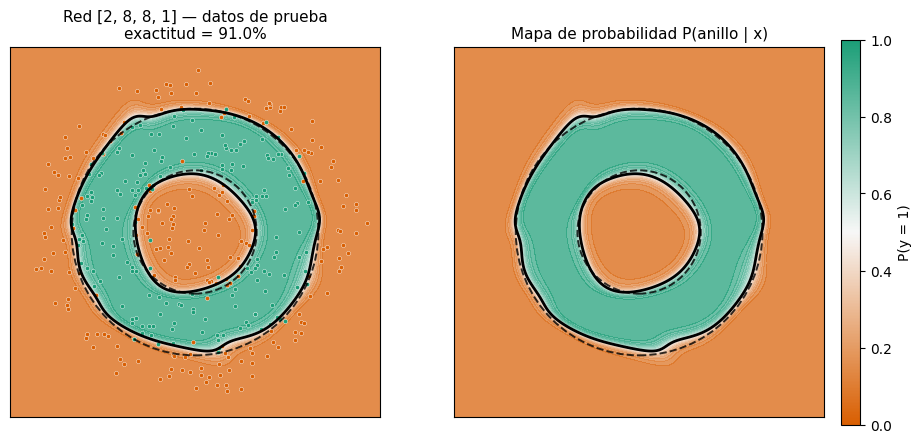

In [38]:
exact_red = accuracy_score(y_pru, red.predecir(X_pru_s))

fig, ejes = plt.subplots(1, 2, figsize=(11, 5))
graficar_frontera(ejes[0], red, X_pru, y_pru, f"Red [2, 8, 8, 1] — datos de prueba\nexactitud = {exact_red:.1%}")
graficar_frontera(ejes[1], red, X_pru, y_pru, "Mapa de probabilidad P(anillo | x)", mostrar_puntos=False)

# Barra de colores para interpretar la probabilidad
sm = plt.cm.ScalarMappable(cmap=MAPA, norm=plt.Normalize(0, 1))
fig.colorbar(sm, ax=ejes, fraction=0.025, pad=0.02, label="P(y = 1)")
plt.show()

La red descubrió por sí sola que la clase depende de la **distancia al centro**, a pesar de que solo recibió las coordenadas $x_1, x_2$ y nunca se le dio el radio. La frontera negra (P = 0.5) sigue muy de cerca a las dos circunferencias reales. Como tiene un número finito de neuronas `tanh`, la frontera no es un círculo perfecto sino una curva suave ligeramente "poligonal".

### 10.3 Métricas de clasificación

- **Matriz de confusión**: cuántos puntos de cada clase real fueron asignados a cada clase predicha.
- **Precisión** (de los que la red dijo "anillo", cuántos lo eran), **exhaustividad / recall** (de los que eran anillo, cuántos detectó) y **F1** (media armónica de ambas).

Reporte de clasificación (conjunto de prueba):

              precision    recall  f1-score   support

   Fuera (0)      0.927     0.910     0.918       222
  Anillo (1)      0.890     0.910     0.900       178

    accuracy                          0.910       400
   macro avg      0.908     0.910     0.909       400
weighted avg      0.910     0.910     0.910       400



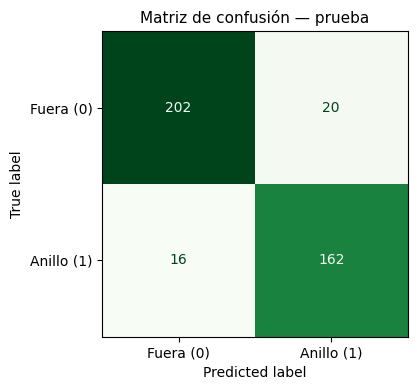

Errores: 36 de 400
Distancia de cada error a la frontera real más cercana (|r − r1| o |r − r2|):
[0.09  0.031 0.018 0.    0.009 0.085 0.007 0.003 0.    0.022 0.037 0.002
 0.029 0.007 0.028 0.023 0.006 0.005 0.004 0.027 0.012 0.059 0.005 0.007
 0.042 0.042 0.041 0.012 0.126 0.046 0.033 0.007 0.002 0.104 0.044 0.018]


In [39]:
y_pred = red.predecir(X_pru_s)

print("Reporte de clasificación (conjunto de prueba):\n")
print(classification_report(y_pru, y_pred, target_names=["Fuera (0)", "Anillo (1)"], digits=3))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_pru, y_pred),
                       display_labels=["Fuera (0)", "Anillo (1)"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Matriz de confusión — prueba")
plt.tight_layout()
plt.show()

# ¿Dónde están los errores? Se espera que estén pegados a las circunferencias, donde actúa el ruido.
errores = y_pred != y_pru
radios_err = np.hypot(X_pru[errores, 0], X_pru[errores, 1])
print(f"Errores: {errores.sum()} de {len(y_pru)}")
print("Distancia de cada error a la frontera real más cercana (|r − r1| o |r − r2|):")
print(np.minimum(np.abs(radios_err - R1), np.abs(radios_err - R2)).round(3))

Los pocos errores ocurren **pegados a las circunferencias**, precisamente donde el ruido gaussiano hace que un punto etiquetado como "anillo" aparezca del otro lado de la frontera (o viceversa). Son errores prácticamente inevitables: la red no está fallando en entender la forma, sino que los datos mismos son ambiguos en esa zona.

### 10.4 ¿Cómo aprende? Evolución de la frontera durante el entrenamiento

Entrenamos otra red idéntica (misma semilla) y vamos tomando "fotografías" de su frontera en distintas épocas.

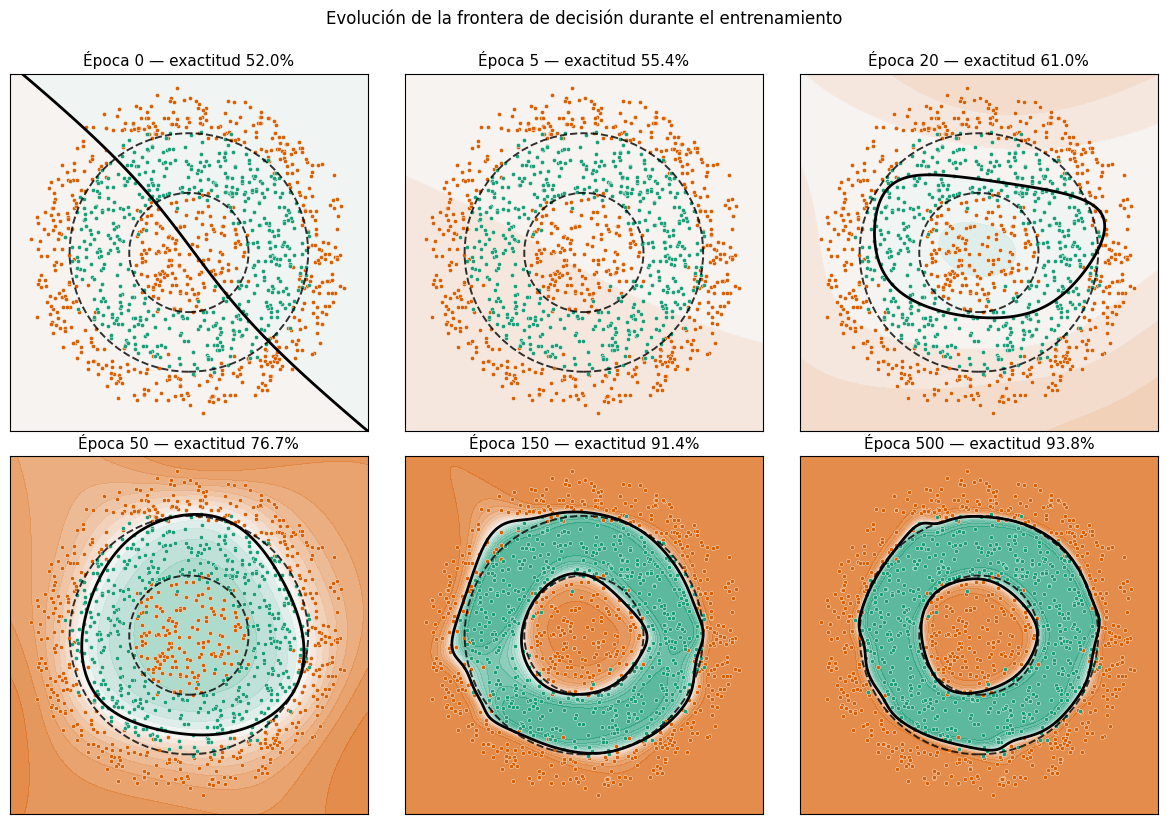

In [40]:
red_evol = RedNeuronal([2, 8, 8, 1], activacion="tanh", tasa_aprendizaje=0.1, decaimiento=0.01, semilla=SEMILLA)
fotos = [0, 5, 20, 50, 150, 500]   # Épocas en las que se toma la "fotografía"

fig, ejes = plt.subplots(2, 3, figsize=(12, 8.2))
for ax, epoca_objetivo in zip(ejes.ravel(), fotos):
    faltan = epoca_objetivo - red_evol.epocas_entrenadas
    if faltan > 0:
        red_evol.entrenar(X_ent_s, Y_ent, epocas=faltan, tam_lote=16)   # Continúa desde donde se quedó
    exact = accuracy_score(y_ent, red_evol.predecir(X_ent_s))
    graficar_frontera(ax, red_evol, X_ent, y_ent, f"Época {epoca_objetivo} — exactitud {exact:.1%}")
fig.suptitle("Evolución de la frontera de decisión durante el entrenamiento", y=1.0)
plt.tight_layout()
plt.show()

Se aprecia claramente **cómo** aprende la red:
- **Época 0:** con pesos aleatorios la frontera es una curva arbitraria sin relación con los datos (≈ 50 % de exactitud).
- **Época 5:** la red se "aplana": predice casi lo mismo en todo el plano (la clase mayoritaria). Es la solución más barata para bajar la pérdida al principio, la misma a la que se quedó atrapado el modelo lineal.
- **Época 20:** aparece una primera región cerrada, todavía deforme y desplazada.
- **Época 50:** la red aprendió un **disco**: ya separa el exterior, pero incluye el hueco central como si fuera anillo.
- **Época 150:** la red "perfora" el centro y aparece la **dona**. Esto muestra que el problema se resolvió **por etapas**: primero la frontera exterior (la más fácil de ver en los datos) y luego la interior.
- **Época 500:** con la tasa de aprendizaje ya reducida por el decaimiento, la forma se afina y se ajusta a ambas circunferencias.

### 10.5 Dentro de la caja: ¿qué aprende cada neurona oculta?

Cada neurona de la **primera capa oculta** calcula $a_j = \tanh(w_{j1}x_1 + w_{j2}x_2 + b_j)$. Como su argumento es lineal, cada una solo puede partir el plano con **una recta** (la línea donde $a_j = 0$), activándose positivamente de un lado (morado) y negativamente del otro (café). Las capas siguientes combinan estas 8 "rectas suaves" para construir el anillo.

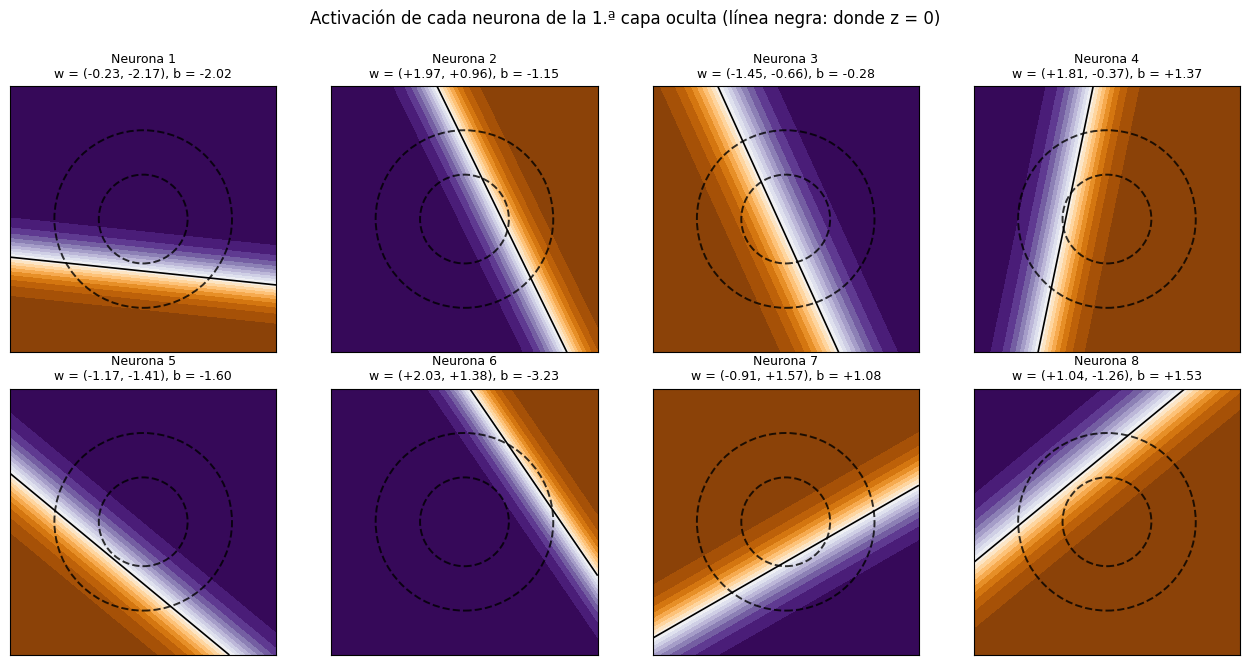

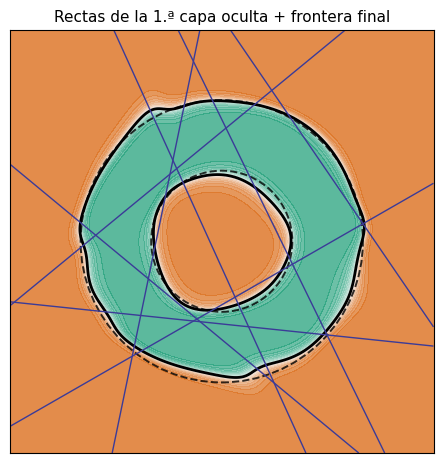

In [41]:
ejes_malla = np.linspace(-1.5, 1.5, 200)
xx, yy = np.meshgrid(ejes_malla, ejes_malla)
malla_s = escalador.transformar(np.column_stack([xx.ravel(), yy.ravel()]))

# Activaciones de la primera capa oculta sobre toda la malla: forma (200*200, 8)
Z1 = malla_s @ red.W[0].T + red.b[0]
A1 = red.g(Z1)

fig, ejes = plt.subplots(2, 4, figsize=(13, 6.6))
for j, ax in enumerate(ejes.ravel()):
    ax.contourf(xx, yy, A1[:, j].reshape(xx.shape), levels=np.linspace(-1, 1, 21), cmap="PuOr_r")
    ax.contour(xx, yy, Z1[:, j].reshape(xx.shape), levels=[0], colors="black", linewidths=1.2)
    dibujar_circulos(ax)
    w = red.W[0][j]
    ax.set_title(f"Neurona {j + 1}\nw = ({w[0]:+.2f}, {w[1]:+.2f}), b = {red.b[0][0, j]:+.2f}", fontsize=9)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Activación de cada neurona de la 1.ª capa oculta (línea negra: donde z = 0)", y=1.0)
plt.tight_layout()
plt.show()

# Todas las rectas juntas sobre la frontera final
fig, ax = plt.subplots(figsize=(5.5, 5.5))
graficar_frontera(ax, red, X_ent, y_ent, "Rectas de la 1.ª capa oculta + frontera final", mostrar_puntos=False)
for j in range(A1.shape[1]):
    ax.contour(xx, yy, Z1[:, j].reshape(xx.shape), levels=[0], colors=["#3b3b98"], linewidths=1, linestyles="-")
plt.show()

Cada panel es una neurona: **ninguna de ellas "sabe" nada sobre círculos**, cada una solo distingue un lado de una recta. La magnitud de $w$ controla qué tan abrupta es la transición (mayor $\lVert w \rVert$ → franja más angosta) y $b$ desplaza la recta respecto al origen. En la última gráfica se ve cómo las 8 rectas azules cruzan la región del anillo con **orientaciones variadas** (casi horizontales, verticales y diagonales), de modo que entre todas "cubren" el círculo desde distintos ángulos; la segunda capa oculta y la neurona de salida combinan esas piezas (sumando, restando y aplicando nuevamente no linealidades) para obtener una región con forma de dona. Esta es la esencia del **aprendizaje de representaciones** jerárquicas que da nombre al aprendizaje profundo: conceptos complejos construidos a partir de piezas simples.

## 11. Experimentos de sensibilidad

Un buen diseño no solo funciona: se entiende **por qué** funciona con esos valores. Variamos un hiperparámetro a la vez manteniendo todo lo demás fijo.

### 11.1 Número de neuronas en una sola capa oculta

¿Cuántas neuronas hacen falta como mínimo? Probamos arquitecturas `[2, h, 1]` con una sola capa oculta.

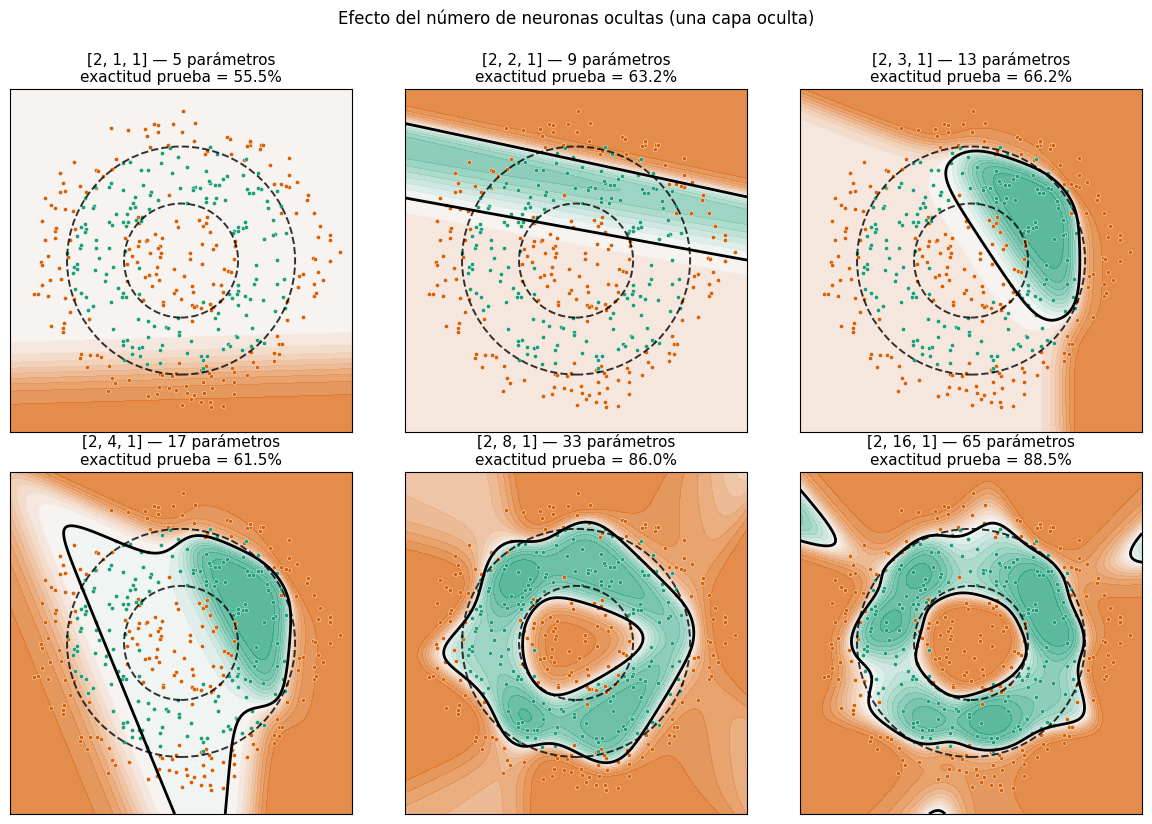

   1 neuronas ocultas → exactitud prueba = 0.555
   2 neuronas ocultas → exactitud prueba = 0.632
   3 neuronas ocultas → exactitud prueba = 0.662
   4 neuronas ocultas → exactitud prueba = 0.615
   8 neuronas ocultas → exactitud prueba = 0.860
  16 neuronas ocultas → exactitud prueba = 0.885


In [42]:
tamanos = [1, 2, 3, 4, 8, 16]
fig, ejes = plt.subplots(2, 3, figsize=(12, 8.2))
resultados_h = {}
for ax, h in zip(ejes.ravel(), tamanos):
    modelo = RedNeuronal([2, h, 1], activacion="tanh", tasa_aprendizaje=0.1, decaimiento=0.01, semilla=SEMILLA)
    modelo.entrenar(X_ent_s, Y_ent, epocas=500, tam_lote=16)
    exact = accuracy_score(y_pru, modelo.predecir(X_pru_s))
    resultados_h[h] = exact
    graficar_frontera(ax, modelo, X_pru, y_pru, f"[2, {h}, 1] — {modelo.n_parametros()} parámetros\nexactitud prueba = {exact:.1%}")
fig.suptitle("Efecto del número de neuronas ocultas (una capa oculta)", y=1.0)
plt.tight_layout()
plt.show()

for h, e in resultados_h.items():
    print(f"  {h:2d} neuronas ocultas → exactitud prueba = {e:.3f}")

### 11.2 Tasa de aprendizaje

Con la arquitectura principal `[2, 8, 8, 1]` comparamos distintos valores **constantes** de $\eta$ (sin decaimiento, para aislar su efecto) contra la configuración elegida ($\eta_0 = 0.1$ con decaimiento).

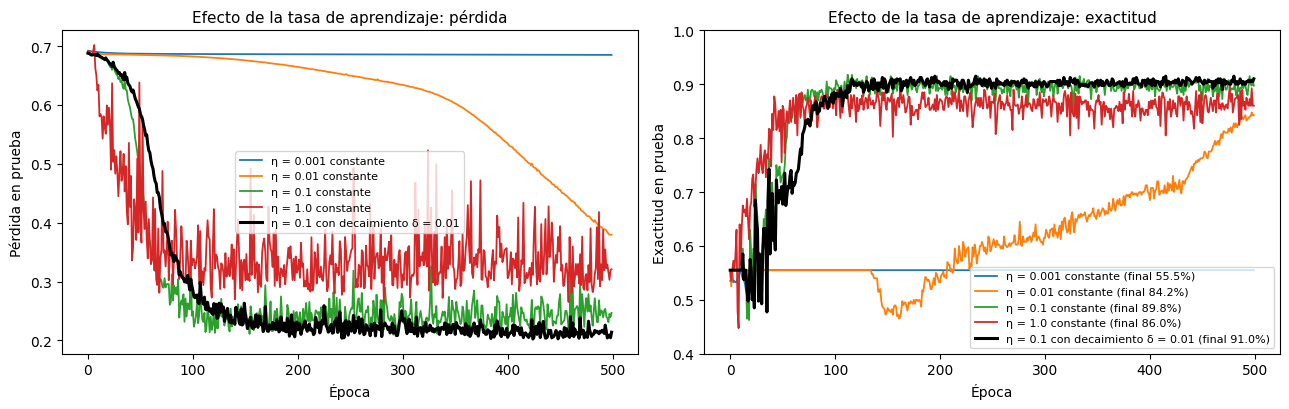

In [43]:
configuraciones = [(0.001, 0.0), (0.01, 0.0), (0.1, 0.0), (1.0, 0.0), (0.1, 0.01)]
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.2))
for eta, dec in configuraciones:
    modelo = RedNeuronal([2, 8, 8, 1], activacion="tanh", tasa_aprendizaje=eta, decaimiento=dec, semilla=SEMILLA)
    modelo.entrenar(X_ent_s, Y_ent, epocas=500, tam_lote=16, x_val=X_pru_s, y_val=Y_pru)
    etiqueta = f"η = {eta}" + (f" con decaimiento δ = {dec}" if dec else " constante")
    estilo = {"lw": 2.2, "c": "black"} if dec else {"lw": 1.3}
    ejes[0].plot(modelo.historial["perdida_val"], label=etiqueta, **estilo)
    ejes[1].plot(modelo.historial["exact_val"],
                 label=f"{etiqueta} (final {modelo.historial['exact_val'][-1]:.1%})", **estilo)
ejes[0].set_xlabel("Época")
ejes[0].set_ylabel("Pérdida en prueba")
ejes[0].set_title("Efecto de la tasa de aprendizaje: pérdida")
ejes[0].legend(fontsize=8)
ejes[1].set_xlabel("Época")
ejes[1].set_ylabel("Exactitud en prueba")
ejes[1].set_title("Efecto de la tasa de aprendizaje: exactitud")
ejes[1].set_ylim(0.4, 1.0)
ejes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

### 11.3 Función de activación en las capas ocultas

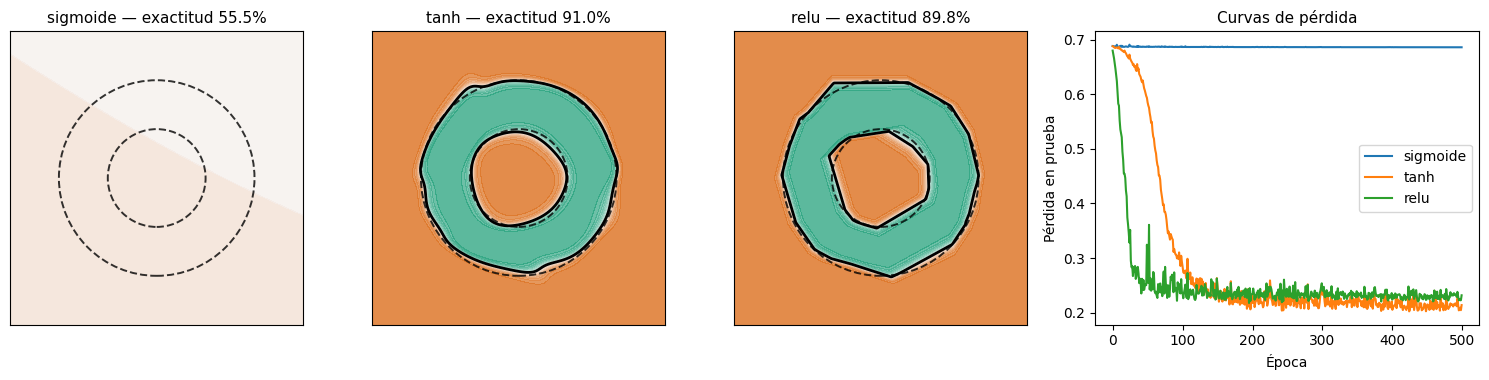

In [45]:
fig, ejes = plt.subplots(1, 4, figsize=(15, 3.9), gridspec_kw={"width_ratios": [1, 1, 1, 1.3]})
for ax, act in zip(ejes[:3], ["sigmoide", "tanh", "relu"]):
    modelo = RedNeuronal([2, 8, 8, 1], activacion=act, tasa_aprendizaje=0.1, decaimiento=0.01, semilla=SEMILLA)
    modelo.entrenar(X_ent_s, Y_ent, epocas=500, tam_lote=16, x_val=X_pru_s, y_val=Y_pru)
    exact = modelo.historial["exact_val"][-1]
    graficar_frontera(ax, modelo, X_pru, y_pru, f"{act} — exactitud {exact:.1%}", mostrar_puntos=False)
    ejes[3].plot(modelo.historial["perdida_val"], label=act)
ejes[3].set_xlabel("Época")
ejes[3].set_ylabel("Pérdida en prueba")
ejes[3].set_title("Curvas de pérdida")
ejes[3].legend()
plt.tight_layout()
plt.show()

### 11.4 Nivel de ruido en los datos

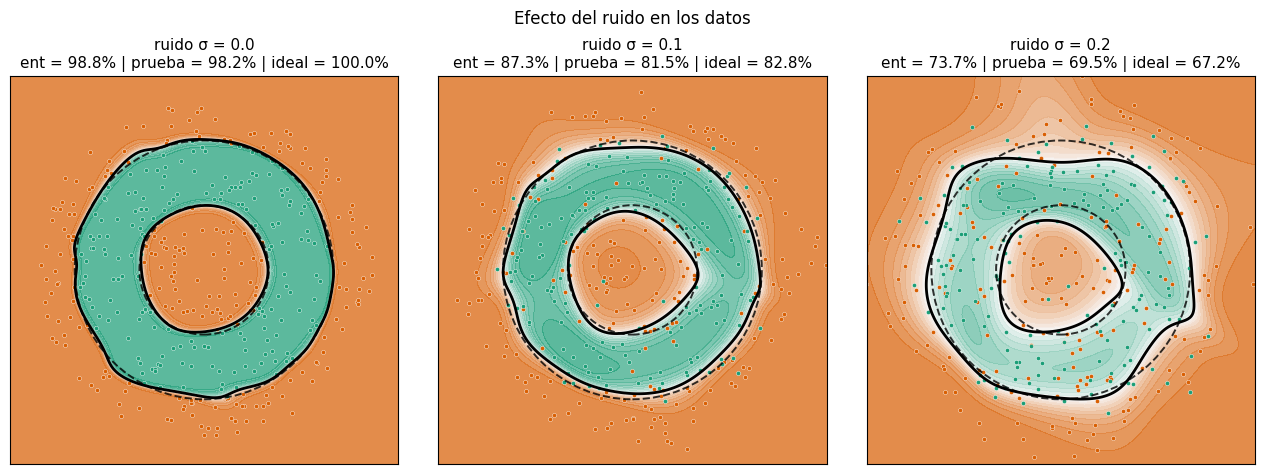

In [46]:
niveles_ruido = [0.0, 0.1, 0.2]
fig, ejes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, ruido in zip(ejes, niveles_ruido):
    Xr, yr = generar_anillo(n=1600, ruido=ruido)
    Xr_ent, Xr_pru, yr_ent, yr_pru = train_test_split(Xr, yr, test_size=0.25, stratify=yr, random_state=SEMILLA)
    # Se reutiliza el escalador global para que graficar_frontera funcione igual
    # (con estos datos centrados la media/desviación prácticamente no cambian).
    modelo = RedNeuronal([2, 8, 8, 1], activacion="tanh", tasa_aprendizaje=0.1, decaimiento=0.01, semilla=SEMILLA)
    modelo.entrenar(escalador.transformar(Xr_ent), yr_ent.reshape(-1, 1), epocas=500, tam_lote=16)
    exact_ent = accuracy_score(yr_ent, modelo.predecir(escalador.transformar(Xr_ent)))
    exact_pru = accuracy_score(yr_pru, modelo.predecir(escalador.transformar(Xr_pru)))
    techo = accuracy_score(yr_pru, regla_ideal(Xr_pru))
    graficar_frontera(ax, modelo, Xr_pru, yr_pru,
                      f"ruido σ = {ruido}\nent = {exact_ent:.1%} | prueba = {exact_pru:.1%} | ideal = {techo:.1%}")
fig.suptitle("Efecto del ruido en los datos", y=1.02)
plt.tight_layout()
plt.show()

### Discusión de los experimentos de sensibilidad

**11.1 Número de neuronas (una capa oculta).**
- Con **1 neurona** el modelo equivale a uno lineal y colapsa a la clase mayoritaria (55.5 %).
- Con **2 neuronas** la red forma una **franja** entre dos rectas paralelas: es la forma más compleja que se logra combinando dos semiplanos.
- Con **3 y 4 neuronas** aparecen regiones más curvas, pero solo cubren un "gajo" del anillo (≈ 62–66 %). Con tan pocas neuronas no es posible rodear el hueco central y además el entrenamiento queda atrapado fácilmente en mínimos locales (4 neuronas incluso quedó peor que 3).
- Con **8 neuronas** ya aparece la dona, aunque con forma poligonal (86 %).
- Con **16 neuronas** la forma mejora (88.5 %), pero aparecen **ondulaciones** y pequeñas regiones espurias en las esquinas, donde no hay datos que corrijan a la red: primeras señales de que sobra capacidad.
- La red principal con **dos capas ocultas de 8** (105 parámetros) logra 91 %, mejor que una sola capa de 16 (65 parámetros) o de 8: la **profundidad** permite combinar las rectas de forma más eficiente, porque la segunda capa trabaja sobre regiones ya construidas por la primera.

**11.2 Tasa de aprendizaje.**
- $\eta = 0.001$: pasos tan pequeños que en 500 épocas la red **no sale de la meseta** inicial.
- $\eta = 0.01$: aprende, pero muy lento; a la época 500 todavía no converge (84 %).
- $\eta = 0.1$ constante: converge rápido, pero la exactitud en prueba **oscila** época a época.
- $\eta = 1.0$: aprende rapidísimo al principio, pero los pasos son tan grandes que la pérdida **rebota** violentamente y nunca se asienta.
- $\eta_0 = 0.1$ con **decaimiento**: combina lo mejor de ambos mundos, velocidad inicial y estabilidad final, y obtiene la mejor exactitud (91 %). Esto justifica la elección de la sección 9.

**11.3 Función de activación.**
- **Sigmoide** se queda atascada en la meseta (55.5 %). Su derivada máxima es 0.25, así que en dos capas ocultas el gradiente se reduce al menos $0.25 \times 0.25 = 1/16$ antes de llegar a la primera capa: es el **desvanecimiento del gradiente** anunciado en la sección 3.8, visible incluso en una red tan pequeña.
- **ReLU** es la que aprende **más rápido** (la pérdida cae en ~20 épocas) y logra 89.8 %. Su frontera tiene **esquinas rectas**: como ReLU es lineal por tramos, la red completa es una función lineal por tramos y la frontera es un polígono.
- **tanh** tarda un poco más en salir de la meseta pero produce una frontera **suave y redondeada**, más parecida a un círculo, y la mejor exactitud (91 %).

**11.4 Ruido.**
- Sin ruido ($\sigma = 0$) el problema es separable y la red llega a 98.2 %; el 1.8 % restante son puntos casi exactamente sobre las circunferencias, donde la red solo aproxima la curva.
- Con $\sigma = 0.1$ la red (81.5 %) queda cerca de la regla ideal (82.8 %).
- Con $\sigma = 0.2$ ocurre algo interesante: la red (69.5 %) **supera** a la "regla ideal" (67.2 %). Con tanto ruido, las circunferencias verdaderas ya no son la mejor frontera para los datos *observados*: al aprender directamente de los datos, la red dibuja un anillo más angosto que se adapta a dónde realmente se concentran los puntos verdes. A la vez, la brecha entre entrenamiento (73.7 %) y prueba (69.5 %) crece: con datos más ruidosos la red empieza a **memorizar ruido** (sobreajuste).

## 12. Comparación con scikit-learn

Para validar que nuestra implementación se comporta como una red "profesional", entrenamos `MLPClassifier` de scikit-learn con la **misma configuración**: capas ocultas (8, 8), `tanh`, descenso de gradiente estocástico sin momento, $\eta = 0.1$, lotes de 16 y 500 épocas.

> **Detalle:** scikit-learn ofrece `learning_rate="invscaling"`, pero su contador $t$ avanza con **cada muestra** (no con cada época), así que $\eta$ se reduce muchísimo más rápido que en nuestra implementación y la red se "congela" antes de aprender el anillo (en una prueba previa se quedó en ~74 %). Por eso aquí se usa $\eta$ constante.

> Los resultados no serán idénticos (distinta inicialización aleatoria, distinto orden de los mini-lotes y la ausencia de decaimiento), pero deberían ser del mismo orden.

Modelo                             Exactitud prueba
Sin capa oculta (NumPy)                       0.555
Red [2, 8, 8, 1] (NumPy, propia)              0.910
MLPClassifier (scikit-learn)                  0.900
Regla ideal (techo teórico)                   0.910


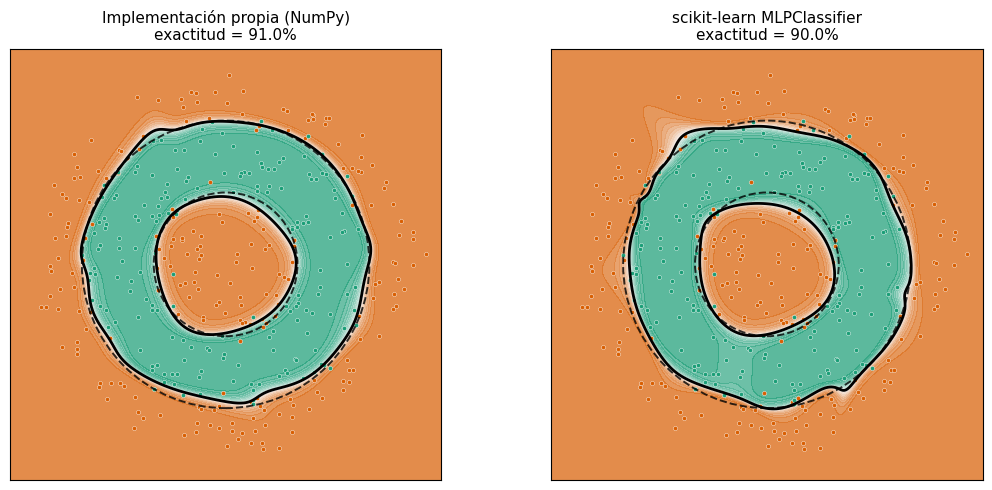

In [47]:
mlp_sk = MLPClassifier(
    hidden_layer_sizes=(8, 8),
    activation="tanh",
    solver="sgd",
    momentum=0.0,               # SGD "puro", igual que nuestra implementación
    learning_rate_init=0.1,
    learning_rate="constant",   # η fija (ver nota de arriba sobre 'invscaling')
    batch_size=16,
    max_iter=500,
    alpha=0.0,                  # Sin regularización L2, para igualar a nuestra red
    n_iter_no_change=500,       # Evita que se detenga antes por falta de mejora
    random_state=SEMILLA,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)   # Aviso esperado: llega al máximo de iteraciones
    mlp_sk.fit(X_ent_s, y_ent)

exact_sk = accuracy_score(y_pru, mlp_sk.predict(X_pru_s))

print(f"{'Modelo':32s} {'Exactitud prueba':>18s}")
print(f"{'Sin capa oculta (NumPy)':32s} {exact_lineal:>18.3f}")
print(f"{'Red [2, 8, 8, 1] (NumPy, propia)':32s} {exact_red:>18.3f}")
print(f"{'MLPClassifier (scikit-learn)':32s} {exact_sk:>18.3f}")
print(f"{'Regla ideal (techo teórico)':32s} {techo_pru:>18.3f}")

fig, ejes = plt.subplots(1, 2, figsize=(11, 5))
graficar_frontera(ejes[0], red, X_pru, y_pru, f"Implementación propia (NumPy)\nexactitud = {exact_red:.1%}")
graficar_frontera(ejes[1], mlp_sk, X_pru, y_pru, f"scikit-learn MLPClassifier\nexactitud = {exact_sk:.1%}")
plt.tight_layout()
plt.show()

Ambas implementaciones llegan a exactitudes prácticamente iguales (~90–91 %) y a fronteras con la misma forma de dona. Que una red escrita desde cero con ~100 líneas de NumPy se comporte igual que la biblioteca de referencia confirma, junto con la verificación de gradientes de la sección 7, que la implementación es correcta.

## 13. Predicción de puntos nuevos

Finalmente usamos la red entrenada como lo haríamos en una aplicación: le damos puntos que no existen en ningún conjunto de datos y le pedimos su predicción. Comparamos con la regla "verdadera" basada en el radio.

             Punto   radio  P(anillo)  predicción  real
(+0.00, +0.00)     0.000      0.012           0     0  ✓
(+0.30, -0.20)     0.361      0.050           0     0  ✓
(+0.75, +0.00)     0.750      0.994           1     1  ✓
(-0.50, +0.50)     0.707      1.000           1     1  ✓
(+0.00, -0.95)     0.950      0.544           1     1  ✓
(+0.90, +0.90)     1.273      0.000           0     0  ✓
(+0.52, +0.00)     0.520      0.717           1     1  ✓
(+1.05, +0.00)     1.050      0.063           0     0  ✓


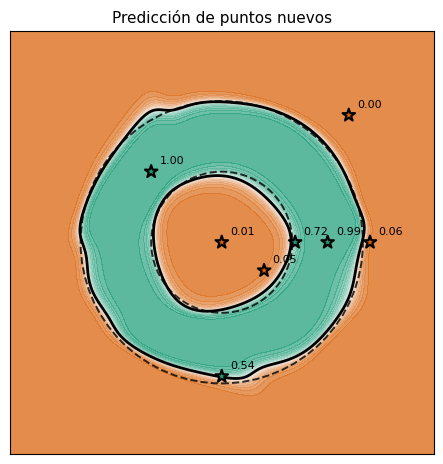

In [48]:
puntos_nuevos = np.array([
    [0.00,  0.00],   # Centro exacto → fuera
    [0.30, -0.20],   # Dentro del hueco central → fuera
    [0.75,  0.00],   # Justo a mitad del anillo → dentro
    [-0.50, 0.50],   # r ≈ 0.707 → dentro
    [0.00, -0.95],   # Cerca del borde exterior → dentro
    [0.90,  0.90],   # r ≈ 1.27 → fuera
    [0.52,  0.00],   # Apenas pasando r1 → dentro (caso difícil)
    [1.05,  0.00],   # Apenas pasando r2 → fuera (caso difícil)
])

# ¡Mismo preprocesamiento que en entrenamiento!
proba = red.predecir_proba(escalador.transformar(puntos_nuevos)).ravel()
pred = (proba >= 0.5).astype(int)

print(f"{'Punto':>18s} {'radio':>7s} {'P(anillo)':>10s} {'predicción':>11s} {'real':>5s}")
for p, pr, c in zip(puntos_nuevos, proba, pred):
    r = np.hypot(*p)
    real = int(R1 <= r <= R2)
    marca = "✓" if c == real else "✗"
    print(f"({p[0]:+.2f}, {p[1]:+.2f})   {r:7.3f} {pr:10.3f} {c:11d} {real:5d}  {marca}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
graficar_frontera(ax, red, X_pru, y_pru, "Predicción de puntos nuevos", mostrar_puntos=False)
ax.scatter(puntos_nuevos[:, 0], puntos_nuevos[:, 1], s=90, c=[COLOR_CLASE[c] for c in pred],
           edgecolors="black", linewidths=1.5, marker="*", zorder=5)
for i, (p, pr) in enumerate(zip(puntos_nuevos, proba)):
    ax.annotate(f"{pr:.2f}", p, textcoords="offset points", xytext=(6, 6), fontsize=8)
plt.show()

La red acierta los 8 puntos, pero lo más interesante son las **probabilidades**:
- Los puntos claramente en el centro, a mitad del anillo o muy afuera reciben probabilidades cercanas a 0 o a 1: la red está **segura**.
- Los puntos pegados a las circunferencias obtienen valores más moderados: r = 0.52 → 0.72 y, sobre todo, (0, −0.95) → **0.54**, prácticamente una moneda al aire. Este último está a solo 0.05 del borde exterior, justo en la zona donde el ruido mezcla ambas clases y donde la frontera aprendida se separa un poco de la circunferencia real (se ve en la gráfica de la sección 10.2, en la parte inferior del anillo).

La red expresa **incertidumbre justo donde los datos son ambiguos**, lo cual es un comportamiento deseable: la salida sigmoide no solo da una clase, también un grado de confianza.

## 14. Conclusiones

1. **La no linealidad y las capas ocultas son indispensables.** El problema del anillo, como XOR, no es linealmente separable. El modelo sin capa oculta quedó en 55.5 %, exactamente la proporción de la clase mayoritaria, con pesos prácticamente nulos: la mejor recta posible no aporta nada. La red `[2, 8, 8, 1]` alcanzó **91.0 % en prueba**, igual al techo de la regla ideal (91.0 %) impuesto por el ruido de los datos.

2. **La red descubre la estructura por sí misma.** Solo recibió coordenadas $(x_1, x_2)$, nunca el radio, y aun así construyó una frontera casi circular. La visualización de la primera capa mostró el mecanismo: cada neurona solo traza una recta, y las capas posteriores combinan esas piezas simples en una forma compleja. Esta es la idea central del aprendizaje profundo: **representaciones jerárquicas** construidas capa por capa.

3. **Backpropagation y descenso de gradiente, desmitificados.** El entrenamiento completo cabe en unas pocas líneas: forward → pérdida → regla de la cadena hacia atrás → actualización. La verificación numérica de gradientes (error relativo ≈ $10^{-10}$) y la comparación con `MLPClassifier` de scikit-learn (90.0 %) confirman que la implementación propia es correcta.

4. **El aprendizaje ocurre por etapas.** La evolución de la frontera mostró una meseta inicial, luego un disco y finalmente la dona perforada. Entender esto explica por qué a veces la pérdida "no baja" al principio y no conviene detener el entrenamiento demasiado pronto.

5. **Los hiperparámetros importan y tienen explicación.**
   - Pocas neuronas no alcanzan para rodear el hueco central; demasiadas generan irregularidades donde no hay datos. Dos capas pequeñas funcionaron mejor que una capa más ancha.
   - Una tasa de aprendizaje muy baja no aprende, una muy alta oscila; el **decaimiento** de $\eta$ dio velocidad y estabilidad.
   - La sigmoide en capas ocultas sufrió **desvanecimiento del gradiente**; tanh dio fronteras suaves y ReLU aprendió más rápido pero con fronteras poligonales.
   - Con más ruido baja el techo alcanzable y aparece el **sobreajuste**.

6. **Limitaciones y trabajo futuro.** El problema es sintético y de dos dimensiones, lo que lo hace ideal para visualizar pero lejano a datos reales. Pasos naturales para las siguientes unidades: usar optimizadores con momento o Adam, regularización (L2, *dropout*) y parada temprana con un conjunto de validación separado del de prueba, reimplementar la red en un framework como PyTorch (usando diferenciación automática en lugar de derivadas a mano) y aplicar la misma arquitectura a problemas con más dimensiones, donde la frontera ya no puede dibujarse pero el mecanismo es exactamente el mismo.

## 15. Referencias

Se listan únicamente las obras citadas en el texto. Las versiones exactas de las bibliotecas utilizadas (NumPy, Matplotlib y scikit-learn) se documentan en la sección 2.

- Cybenko, G. (1989). Approximation by superpositions of a sigmoidal function. *Mathematics of Control, Signals and Systems*, 2(4), 303–314. https://doi.org/10.1007/BF02551274
- Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. *Proceedings of the 13th International Conference on Artificial Intelligence and Statistics (AISTATS)*, PMLR 9, 249–256.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. https://www.deeplearningbook.org — Cap. 6: Deep Feedforward Networks.
- He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification. *Proceedings of the IEEE International Conference on Computer Vision (ICCV)*, 1026–1034.
- Hornik, K. (1991). Approximation capabilities of multilayer feedforward networks. *Neural Networks*, 4(2), 251–257.
- Minsky, M., & Papert, S. (1969). *Perceptrons: An Introduction to Computational Geometry*. MIT Press.
- Nielsen, M. A. (2015). *Neural Networks and Deep Learning*. Determination Press. http://neuralnetworksanddeeplearning.com
- Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature*, 323, 533–536. https://doi.org/10.1038/323533a0
- RKCbas. *Maestría en Inteligencia Artificial - Prácticas* [Repositorio de GitHub]. Práctica 1.1, Aprendizaje profundo: Red neuronal usando Python. Disponible en: <https://github.com/RKCbas/LENGUAJES-DE-CIENCIA-DE-DATOS-B-SICO---PRACTICAS/blob/main/Cuatrimestre%204/8%20-%20Aprendizaje%20profundo/Practica%201.1/Red%20neuronal%20usando%20Python.ipynb>